# Binary Classification - Reviewer 3 Rebuild

This notebook rebuilds the binary attack-vs-benign experiment for Reviewer 3.

Main rules:
- All models use the same processed binary feature matrix.
- All classical models and the neural baseline use Optuna with 40 trials.
- The Optuna objective is F1-Binary.
- Threshold calibration uses a held-out calibration split, not the test set.
- The final test set is used only once for final reporting.

Data protocol:

```text
processed train split
|-- fit pool: training + Optuna sample
`-- calibration pool: threshold selection + SHAP sample

processed test split: final evaluation only
```

## Step 1: Setup

Load the required libraries and set the shared experiment settings.

### 1.1 Import libraries

In [1]:
# 1.1 Import libraries
import gc
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb

### 1.2 Import model and metric tools

In [2]:
# 1.2 Import model and metric tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier

### 1.3 Import PyTorch for the neural baseline

In [3]:
# 1.3 Import PyTorch for the neural baseline
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

### 1.4 Set experiment controls

In [4]:
# 1.4 Set experiment controls
RANDOM_STATE = 42
N_TRIALS = 40

CALIB_SIZE = 0.15
TUNE_VALID_SIZE = 0.20
RUN_STABILITY_CHECK = True
STABILITY_FOLDS = 3

SMOKE_TEST = False
if SMOKE_TEST:
    N_TRIALS = 2
    RUN_STABILITY_CHECK = False

### 1.5 Set threshold and MLP settings

In [5]:
# 1.5 Set threshold and MLP settings
TARGET_MISS_RATE = 1.0
MAX_ACCEPTABLE_FAR = 15.0
THRESHOLDS = np.round(np.arange(0.05, 0.951, 0.01), 2)

MLP_TRIAL_EPOCHS = 25
MLP_FINAL_EPOCHS = 50
MLP_PATIENCE = 6

### 1.6 Locate the project folders

In [6]:
# 1.6 Locate the project folders
NOTEBOOK_DIR = Path.cwd().resolve()
known_project_path = (
    NOTEBOOK_DIR
    / "prepared_final-20260304T163925Z-3-001"
    / "prepared_final"
    / "ML Project_ FINAL"
    / "Hierarchical IoT Intrusion Detection"
    / "Hierarchical-IoT-Intrusion-Detection"
)

project_candidates = [NOTEBOOK_DIR, known_project_path, *NOTEBOOK_DIR.parents]
PROJECT_ROOT = None
for candidate in project_candidates:
    marker = candidate / "Preprosecing step" / "01_data_preprocessing.py"
    if marker.exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Project root was not found.")

results_dir = PROJECT_ROOT / "results" / "reviewer3_binary"
models_dir = PROJECT_ROOT / "models" / "reviewer3_binary"
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results dir:", results_dir)
print("Models dir:", models_dir)

Project root: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection
Results dir: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary
Models dir: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\models\reviewer3_binary


### 1.7 Find the processed-data folder

In [7]:
# 1.7 Find the processed-data folder
processed_candidates = [
    Path.cwd() / "processed_data",
    PROJECT_ROOT / "processed_data",
    PROJECT_ROOT / "Preprosecing step" / "processed_data",
    NOTEBOOK_DIR / ".." / "processed_data",
]

for parent in NOTEBOOK_DIR.parents:
    processed_candidates.append(parent / "processed_data")

processed_dir = None
for candidate in processed_candidates:
    candidate = candidate.resolve()
    if (candidate / "train_data.npz").exists() and (candidate / "test_data.npz").exists():
        processed_dir = candidate
        break

if processed_dir is None:
    checked = "\n".join(str(p.resolve()) for p in processed_candidates)
    raise FileNotFoundError("Run 01_data_preprocessing.py first.\n" + checked)

print("Processed data:", processed_dir)

Processed data: D:\Ml Project\processed_data


### 1.8 Select CPU or GPU

In [8]:
# 1.8 Select CPU or GPU
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
xgb_device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch device:", device)
print("XGBoost requested device:", xgb_device)
if torch.cuda.is_available():
    print("CUDA name:", torch.cuda.get_device_name(0))

PyTorch device: cuda
XGBoost requested device: cuda
CUDA name: NVIDIA RTX 5000 Ada Generation


## Step 2: Load and Audit Data

Use the exact processed arrays from the preprocessing step. No model-specific feature engineering is added here.

### 2.1 Load saved preprocessing outputs

In [9]:
# 2.1 Load saved preprocessing outputs
train_npz = np.load(processed_dir / "train_data.npz")
test_npz = np.load(processed_dir / "test_data.npz")

metadata = joblib.load(processed_dir / "metadata.joblib")
feature_columns = joblib.load(processed_dir / "feature_columns.joblib")
binary_class_weights = joblib.load(processed_dir / "binary_class_weights.joblib")
scaler = joblib.load(processed_dir / "scaler.joblib")

### 2.2 Load binary arrays

In [10]:
# 2.2 Load binary arrays
X_train_full = train_npz["X"].astype(np.float32)
y_train_full = train_npz["y_binary"].astype(np.int64)

X_test = test_npz["X"].astype(np.float32)
y_test = test_npz["y_binary"].astype(np.int64)

feature_names = list(metadata["feature_names"])

### 2.3 Confirm the feature protocol

In [11]:
# 2.3 Confirm the feature protocol
assert feature_columns == feature_names
assert X_train_full.shape[1] == metadata["n_features"]
assert X_test.shape[1] == metadata["n_features"]

print("Feature count:", len(feature_names))
print("Scaler:", type(scaler).__name__)
print("Train shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Feature count: 46
Scaler: RobustScaler
Train shape: (5599994, 46)
Test shape: (1399999, 46)


### 2.4 Check labels and missing values

In [12]:
# 2.4 Check labels and missing values
assert set(np.unique(y_train_full)).issubset({0, 1})
assert set(np.unique(y_test)).issubset({0, 1})
assert np.isfinite(X_train_full).all()
assert np.isfinite(X_test).all()

print("Train labels:", np.bincount(y_train_full))
print("Test labels:", np.bincount(y_test))

Train labels: [ 878556 4721438]
Test labels: [ 219639 1180360]


## Step 3: Internal Split

The calibration pool is held out from supervised training. It is used for threshold selection and SHAP sampling only.

### 3.1 Split fit pool and calibration pool

In [13]:
# 3.1 Split fit pool and calibration pool
all_rows = np.arange(len(y_train_full))
fit_rows, calib_rows = train_test_split(
    all_rows,
    test_size=CALIB_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

X_fit_pool = X_train_full[fit_rows]
y_fit_pool = y_train_full[fit_rows]
X_calib = X_train_full[calib_rows]
y_calib = y_train_full[calib_rows]

### 3.2 Free the original train array

In [14]:
# 3.2 Free the original train array
del X_train_full, y_train_full
gc.collect()

print("Fit pool:", X_fit_pool.shape, np.bincount(y_fit_pool))
print("Calibration:", X_calib.shape, np.bincount(y_calib))

Fit pool: (4759994, 46) [ 746772 4013222]
Calibration: (840000, 46) [131784 708216]


### 3.3 Compute XGBoost class balance

In [15]:
# 3.3 Compute XGBoost class balance
fit_counts = np.bincount(y_fit_pool)
xgb_scale_pos_weight = fit_counts[0] / fit_counts[1]
metadata_scale_pos_weight = float(metadata.get("scale_pos_weight", xgb_scale_pos_weight))
xgb_scale_pos_weight_options = sorted({float(xgb_scale_pos_weight), metadata_scale_pos_weight, 1.0})

print("Fit counts [Benign, Attack]:", fit_counts)
print("XGBoost scale_pos_weight options:", xgb_scale_pos_weight_options)

Fit counts [Benign, Attack]: [ 746772 4013222]
XGBoost scale_pos_weight options: [0.1860779194373, 1.0, 5.374088845787861]


### 3.4 Use the full fit pool for tuning

In [16]:
# 3.4 Use the full fit pool for tuning
X_tune = X_fit_pool
y_tune = y_fit_pool

print("Tuning data:", X_tune.shape, np.bincount(y_tune))
print("Protocol: Optuna uses the full fit pool, then final models refit on the full fit pool.")

Tuning data: (4759994, 46) [ 746772 4013222]
Protocol: Optuna uses the full fit pool, then final models refit on the full fit pool.


### 3.5 Split tuning train and validation

In [17]:
# 3.5 Split tuning train and validation
tune_index = np.arange(len(y_tune))
tune_train_rows, tune_valid_rows = train_test_split(
    tune_index,
    test_size=TUNE_VALID_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_tune,
)

X_tune_train = X_tune[tune_train_rows]
y_tune_train = y_tune[tune_train_rows]
X_tune_valid = X_tune[tune_valid_rows]
y_tune_valid = y_tune[tune_valid_rows]

print("Tune train:", X_tune_train.shape)
print("Tune valid:", X_tune_valid.shape)

Tune train: (3807995, 46)
Tune valid: (951999, 46)


### 3.6 Remove the temporary tuning array

In [18]:
# 3.6 Remove the temporary tuning array
del X_tune, y_tune
gc.collect()

0

## Step 4: Shared Evaluation Logic

These helpers are intentionally small. They keep the metrics and threshold policy identical for every model.

### 4.1 Compute the required binary metrics

In [19]:
# 4.1 Compute the required binary metrics
def binary_metrics(y_true, y_pred, y_prob=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    miss_rate = fn / (fn + tp) * 100 if (fn + tp) else 0.0
    far = fp / (fp + tn) * 100 if (fp + tn) else 0.0

    row = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Attack Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Binary": f1_score(y_true, y_pred, average="binary", zero_division=0),
        "F1-Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-Micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "F1-Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Attack Miss Rate (%)": miss_rate,
        "False Alarm Rate (%)": far,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }
    return row

### 4.2 Add ROC-AUC and PR-AUC when probabilities exist

In [20]:
# 4.2 Add ROC-AUC and PR-AUC when probabilities exist
def add_auc_metrics(row, y_true, y_prob):
    row["ROC-AUC"] = np.nan
    row["PR-AUC"] = np.nan
    if y_prob is None:
        return row

    try:
        row["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        pass
    try:
        row["PR-AUC"] = average_precision_score(y_true, y_prob)
    except ValueError:
        pass
    return row

### 4.3 Select the operating threshold

In [21]:
# 4.3 Select the operating threshold
def choose_threshold(y_true, y_prob):
    rows = []
    for threshold in THRESHOLDS:
        y_pred = (y_prob >= threshold).astype(np.int64)
        row = binary_metrics(y_true, y_pred, y_prob)
        row["Threshold"] = float(threshold)
        rows.append(row)

    table = pd.DataFrame(rows)
    good = table[table["Attack Miss Rate (%)"] <= TARGET_MISS_RATE]

    if not good.empty:
        pick = good.sort_values(["False Alarm Rate (%)", "F1-Binary"], ascending=[True, False]).iloc[0]
        return float(pick["Threshold"]), table, "target_miss_then_lowest_far"

    good = table[table["False Alarm Rate (%)"] <= MAX_ACCEPTABLE_FAR]
    if not good.empty:
        pick = good.sort_values(["Attack Miss Rate (%)", "F1-Binary"], ascending=[True, False]).iloc[0]
        return float(pick["Threshold"]), table, "lowest_miss_under_far_limit"

    pick = table.sort_values(["F1-Binary", "Attack Miss Rate (%)"], ascending=[False, True]).iloc[0]
    return float(pick["Threshold"]), table, "best_f1_tradeoff"

### 4.4 Prepare result storage

In [22]:
# 4.4 Prepare result storage
results = []
best_params = {}
threshold_notes = {}
saved_predictions = {}
saved_probabilities = {}

## Step 5: Decision Tree

This is the simplest tree baseline. It uses the same features, tuning split, and final test protocol.

### 5.1 Tune Decision Tree with Optuna

In [23]:
# 5.1 Tune Decision Tree with Optuna
def objective_dt(trial):
    # This space keeps the old notebook values and adds safer large-data pruning options.
    params = {
        "max_depth": trial.suggest_categorical("max_depth", [6, 10, 15, 20, 25, 30, 35, 40, None]),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 5, 10, 20, 50, 100, 250, 500, 1000, 2000, 5000]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [1, 2, 4, 8, 20, 50, 100, 250, 500, 1000, 2000]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "ccp_alpha": trial.suggest_categorical("ccp_alpha", [0.0, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
    }
    model = DecisionTreeClassifier(**params)
    model.fit(X_tune_train, y_tune_train)
    y_pred = model.predict(X_tune_valid)
    return f1_score(y_tune_valid, y_pred, average="binary", zero_division=0)


start = time.perf_counter()
study_dt = optuna.create_study(direction="maximize")
study_dt.optimize(objective_dt, n_trials=N_TRIALS, n_jobs=-1, gc_after_trial=True)
tuning_time_dt = time.perf_counter() - start

### 5.2 Train final Decision Tree

In [24]:
# 5.2 Train final Decision Tree
dt_params = study_dt.best_params.copy()
dt_params.update({"class_weight": "balanced", "random_state": RANDOM_STATE})

start = time.perf_counter()
dt_model = DecisionTreeClassifier(**dt_params)
dt_model.fit(X_fit_pool, y_fit_pool)
training_time_dt = time.perf_counter() - start

joblib.dump(dt_model, models_dir / "decision_tree_optuna40.joblib")
best_params["Decision Tree"] = dt_params

### 5.3 Calibrate Decision Tree threshold

In [25]:
# 5.3 Calibrate Decision Tree threshold
dt_calib_prob = dt_model.predict_proba(X_calib)[:, 1]
dt_threshold, dt_threshold_table, dt_reason = choose_threshold(y_calib, dt_calib_prob)
dt_threshold_table.to_csv(results_dir / "decision_tree_thresholds.csv", index=False)

threshold_notes["Decision Tree"] = {"threshold": dt_threshold, "reason": dt_reason}
print("Decision Tree threshold:", dt_threshold, dt_reason)

Decision Tree threshold: 0.15 target_miss_then_lowest_far


### 5.4 Evaluate Decision Tree on the test set

In [26]:
# 5.4 Evaluate Decision Tree on the test set
start = time.perf_counter()
dt_test_prob = dt_model.predict_proba(X_test)[:, 1]
dt_inference_time = time.perf_counter() - start

dt_test_pred = (dt_test_prob >= dt_threshold).astype(np.int64)
dt_row = binary_metrics(y_test, dt_test_pred, dt_test_prob)
dt_row = add_auc_metrics(dt_row, y_test, dt_test_prob)
dt_row.update({
    "Model": "Decision Tree",
    "Threshold": dt_threshold,
    "Threshold Reason": dt_reason,
    "Tuning Time (s)": tuning_time_dt,
    "Training Time (s)": training_time_dt,
    "Inference Time (s)": dt_inference_time,
    "Inference Time per Flow (us)": dt_inference_time / len(X_test) * 1_000_000,
})

results.append(dt_row)
saved_predictions["Decision Tree"] = dt_test_pred
saved_probabilities["Decision Tree"] = dt_test_prob
pd.DataFrame([dt_row])

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,TP,ROC-AUC,PR-AUC,Model,Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,0.986527,0.993707,0.990292,0.991996,0.974725,0.986527,0.986577,0.949507,0.970806,3.370531,...,1168901,0.996933,0.999137,Decision Tree,0.15,target_miss_then_lowest_far,139.439641,60.570803,0.091344,0.065246


## Step 6: Random Forest

Random Forest is the stronger bagging baseline. It is tuned with the same Optuna budget.

### 6.1 Tune Random Forest with Optuna

In [27]:
# 6.1 Tune Random Forest with Optuna
def objective_rf(trial):
    # Original RandomizedSearch values are included, with a few extra regularized choices.
    params = {
        "n_estimators": trial.suggest_categorical("n_estimators", [100, 150, 200, 250, 300, 400, 500]),
        "max_depth": trial.suggest_categorical("max_depth", [15, 20, 25, 30, 40, 50, None]),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 5, 10, 20, 50, 100]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [1, 2, 4, 8, 10, 20, 50]),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": "balanced",
        "n_jobs": -1,
        "random_state": RANDOM_STATE,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_tune_train, y_tune_train)
    y_pred = model.predict(X_tune_valid)
    return f1_score(y_tune_valid, y_pred, average="binary", zero_division=0)


start = time.perf_counter()
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=N_TRIALS, n_jobs=1, gc_after_trial=True)
tuning_time_rf = time.perf_counter() - start

### 6.2 Train final Random Forest

In [28]:
# 6.2 Train final Random Forest
rf_params = study_rf.best_params.copy()
rf_params.update({"class_weight": "balanced", "n_jobs": -1, "random_state": RANDOM_STATE})

start = time.perf_counter()
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_fit_pool, y_fit_pool)
training_time_rf = time.perf_counter() - start

joblib.dump(rf_model, models_dir / "random_forest_optuna40.joblib")
best_params["Random Forest"] = rf_params

### 6.3 Calibrate Random Forest threshold

In [29]:
# 6.3 Calibrate Random Forest threshold
rf_calib_prob = rf_model.predict_proba(X_calib)[:, 1]
rf_threshold, rf_threshold_table, rf_reason = choose_threshold(y_calib, rf_calib_prob)
rf_threshold_table.to_csv(results_dir / "random_forest_thresholds.csv", index=False)

threshold_notes["Random Forest"] = {"threshold": rf_threshold, "reason": rf_reason}
print("Random Forest threshold:", rf_threshold, rf_reason)

Random Forest threshold: 0.42 target_miss_then_lowest_far


### 6.4 Evaluate Random Forest on the test set

In [30]:
# 6.4 Evaluate Random Forest on the test set
start = time.perf_counter()
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]
rf_inference_time = time.perf_counter() - start

rf_test_pred = (rf_test_prob >= rf_threshold).astype(np.int64)
rf_row = binary_metrics(y_test, rf_test_pred, rf_test_prob)
rf_row = add_auc_metrics(rf_row, y_test, rf_test_prob)
rf_row.update({
    "Model": "Random Forest",
    "Threshold": rf_threshold,
    "Threshold Reason": rf_reason,
    "Tuning Time (s)": tuning_time_rf,
    "Training Time (s)": training_time_rf,
    "Inference Time (s)": rf_inference_time,
    "Inference Time per Flow (us)": rf_inference_time / len(X_test) * 1_000_000,
})

results.append(rf_row)
saved_predictions["Random Forest"] = rf_test_pred
saved_probabilities["Random Forest"] = rf_test_prob
pd.DataFrame([rf_row])

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,TP,ROC-AUC,PR-AUC,Model,Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,0.988088,0.995648,0.9902,0.992916,0.977751,0.988088,0.988158,0.955645,0.98004,2.32609,...,1168792,0.998853,0.999793,Random Forest,0.42,target_miss_then_lowest_far,13227.308782,705.834088,9.96702,7.119305


## Step 7: XGBoost

XGBoost is the main tabular model. The code tries GPU first and falls back to CPU if needed.

### 7.1 Tune XGBoost with Optuna

In [31]:
# 7.1 Tune XGBoost with Optuna
def objective_xgb(trial):
    # The original XGBoost Optuna range is fully covered here.
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "scale_pos_weight": trial.suggest_categorical("scale_pos_weight", xgb_scale_pos_weight_options),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "tree_method": "hist",
        "device": xgb_device,
        "random_state": RANDOM_STATE,
    }
    model = xgb.XGBClassifier(**params)
    try:
        model.fit(X_tune_train, y_tune_train)
    except Exception:
        params["device"] = "cpu"
        model = xgb.XGBClassifier(**params)
        model.fit(X_tune_train, y_tune_train)
    return f1_score(y_tune_valid, model.predict(X_tune_valid), average="binary", zero_division=0)

### 7.2 Run the XGBoost study

In [32]:
# 7.2 Run the XGBoost study
start = time.perf_counter()
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, n_jobs=-1, gc_after_trial=True)
tuning_time_xgb = time.perf_counter() - start

### 7.3 Train final XGBoost

In [33]:
# 7.3 Train final XGBoost
xgb_params = study_xgb.best_params.copy()
xgb_params.update({
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "device": xgb_device,
    "random_state": RANDOM_STATE,
})

start = time.perf_counter()
xgb_model = xgb.XGBClassifier(**xgb_params)
try:
    xgb_model.fit(X_fit_pool, y_fit_pool)
except Exception:
    xgb_params["device"] = "cpu"
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_fit_pool, y_fit_pool)
training_time_xgb = time.perf_counter() - start

### 7.4 Save final XGBoost

In [34]:
# 7.4 Save final XGBoost
joblib.dump(xgb_model, models_dir / "xgboost_optuna40.joblib")
best_params["XGBoost"] = xgb_params

print("Final XGBoost device:", xgb_params["device"])

Final XGBoost device: cuda


### 7.5 Calibrate XGBoost threshold

In [35]:
# 7.5 Calibrate XGBoost threshold
xgb_calib_prob = xgb_model.predict_proba(X_calib)[:, 1]
xgb_threshold, xgb_threshold_table, xgb_reason = choose_threshold(y_calib, xgb_calib_prob)
xgb_threshold_table.to_csv(results_dir / "xgboost_thresholds.csv", index=False)

threshold_notes["XGBoost"] = {"threshold": xgb_threshold, "reason": xgb_reason}
print("XGBoost threshold:", xgb_threshold, xgb_reason)

XGBoost threshold: 0.53 target_miss_then_lowest_far


### 7.6 Evaluate XGBoost on the test set

In [36]:
# 7.6 Evaluate XGBoost on the test set
start = time.perf_counter()
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_inference_time = time.perf_counter() - start

xgb_test_pred = (xgb_test_prob >= xgb_threshold).astype(np.int64)
xgb_row = binary_metrics(y_test, xgb_test_pred, xgb_test_prob)
xgb_row = add_auc_metrics(xgb_row, y_test, xgb_test_prob)
xgb_row.update({
    "Model": "XGBoost",
    "Threshold": xgb_threshold,
    "Threshold Reason": xgb_reason,
    "Tuning Time (s)": tuning_time_xgb,
    "Training Time (s)": training_time_xgb,
    "Inference Time (s)": xgb_inference_time,
    "Inference Time per Flow (us)": xgb_inference_time / len(X_test) * 1_000_000,
})

results.append(xgb_row)
saved_predictions["XGBoost"] = xgb_test_pred
saved_probabilities["XGBoost"] = xgb_test_prob
pd.DataFrame([xgb_row])

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,TP,ROC-AUC,PR-AUC,Model,Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,0.988406,0.995812,0.990413,0.993105,0.978342,0.988406,0.988473,0.956826,0.958691,2.238218,...,1169044,0.999024,0.999822,XGBoost,0.53,target_miss_then_lowest_far,181.77967,12.903665,0.778192,0.555852


## Step 8: MLP Neural Network

This is the supervised neural baseline requested by the reviewers. It uses the same features and the same Optuna trial budget.

### 8.1 Prepare class weights

In [37]:
# 8.1 Prepare class weights
w0 = float(binary_class_weights.get(0, binary_class_weights.get("0", 1.0)))
w1 = float(binary_class_weights.get(1, binary_class_weights.get("1", 1.0)))
mlp_class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=device)

print("MLP class weights:", mlp_class_weights)

MLP class weights: tensor([3.1870, 0.5930], device='cuda:0')


### 8.2 Define the MLP model

In [38]:
# 8.2 Define the MLP model
class BinaryMLP(nn.Module):
    def __init__(self, n_features, hidden_sizes, dropout):
        super().__init__()
        layers = []
        in_features = n_features

        for hidden in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden))
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_features = hidden

        layers.append(nn.Linear(in_features, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

### 8.3 Build a PyTorch DataLoader

In [39]:
# 8.3 Build a PyTorch DataLoader
def make_loader(X, y, batch_size, shuffle):
    X_tensor = torch.from_numpy(np.asarray(X, dtype=np.float32))
    y_tensor = torch.from_numpy(np.asarray(y, dtype=np.int64))
    data = TensorDataset(X_tensor, y_tensor)
    return DataLoader(
        data,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

### 8.4 Predict MLP probabilities

In [40]:
# 8.4 Predict MLP probabilities
@torch.no_grad()
def mlp_predict_proba(model, X, batch_size):
    model.eval()
    dummy_y = np.zeros(len(X), dtype=np.int64)
    loader = make_loader(X, dummy_y, batch_size=batch_size, shuffle=False)
    parts = []

    for xb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        parts.append(prob)

    return np.concatenate(parts)

### 8.5 Train one MLP epoch

In [41]:
# 8.5 Train one MLP epoch
def train_one_mlp_epoch(model, loader, criterion, optimizer):
    model.train()
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

### 8.6 Sample MLP hyperparameters

In [42]:
# 8.6 Sample MLP hyperparameters
def sample_mlp_params(trial):
    n_layers = trial.suggest_int("n_layers", 2, 5)

    hidden_options = {
        1: [128, 256, 512, 768, 1024],
        2: [64, 128, 256, 512, 768],
        3: [32, 64, 128, 256, 512],
        4: [32, 64, 128, 256],
        5: [16, 32, 64, 128],
    }

    hidden_sizes = []
    for layer_id in range(1, n_layers + 1):
        hidden_sizes.append(
            trial.suggest_categorical(
                f"hidden_{layer_id}",
                hidden_options[layer_id],
            )
        )

    return {
        "hidden_sizes": hidden_sizes,
        "dropout": trial.suggest_float("dropout", 0.05, 0.6),
        "learning_rate": trial.suggest_float("learning_rate", 5e-5, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-7, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [1024, 2048, 4096, 8192, 16384]),
    }

### 8.7 Tune MLP with Optuna

In [43]:
# 8.7 Tune MLP with Optuna
def objective_mlp(trial):
    params = sample_mlp_params(trial)
    batch_size = params["batch_size"]
    model = BinaryMLP(X_fit_pool.shape[1], params["hidden_sizes"], params["dropout"]).to(device)
    loader = make_loader(X_tune_train, y_tune_train, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss(weight=mlp_class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

    best_score, stale_epochs = -1.0, 0
    for epoch in range(MLP_TRIAL_EPOCHS):
        train_one_mlp_epoch(model, loader, criterion, optimizer)
        y_prob = mlp_predict_proba(model, X_tune_valid, batch_size)
        y_pred = (y_prob >= 0.5).astype(np.int64)
        score = f1_score(y_tune_valid, y_pred, average="binary", zero_division=0)

        trial.report(score, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        if score > best_score:
            best_score = score
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= MLP_PATIENCE:
            break

    return best_score

### 8.8 Run the MLP study

In [44]:
# 8.8 Run the MLP study
start = time.perf_counter()
study_mlp = optuna.create_study(direction="maximize")
study_mlp.optimize(objective_mlp, n_trials=N_TRIALS, n_jobs=1, gc_after_trial=True)
tuning_time_mlp = time.perf_counter() - start

In [45]:
# Check best MLP parameters before final training
study_mlp.best_params

{'n_layers': 5,
 'hidden_1': 1024,
 'hidden_2': 512,
 'hidden_3': 512,
 'hidden_4': 128,
 'hidden_5': 64,
 'dropout': 0.12933788731746465,
 'learning_rate': 0.0015340148967827093,
 'weight_decay': 7.766238665193131e-05,
 'batch_size': 16384}

In [46]:
# Check final MLP training cost
print("MLP_FINAL_EPOCHS:", MLP_FINAL_EPOCHS)
print("Best MLP params:", study_mlp.best_params)

MLP_FINAL_EPOCHS: 50
Best MLP params: {'n_layers': 5, 'hidden_1': 1024, 'hidden_2': 512, 'hidden_3': 512, 'hidden_4': 128, 'hidden_5': 64, 'dropout': 0.12933788731746465, 'learning_rate': 0.0015340148967827093, 'weight_decay': 7.766238665193131e-05, 'batch_size': 16384}


### 8.9 Train final MLP

In [49]:
# 8.9 Train final MLP
mlp_params = study_mlp.best_params.copy()

hidden_sizes = []
for layer_id in range(1, mlp_params["n_layers"] + 1):
    hidden_sizes.append(mlp_params[f"hidden_{layer_id}"])

mlp_params["hidden_sizes"] = hidden_sizes
mlp_batch_size = int(mlp_params["batch_size"])
mlp_loader = make_loader(X_fit_pool, y_fit_pool, batch_size=mlp_batch_size, shuffle=True)
mlp_model = BinaryMLP(X_fit_pool.shape[1], hidden_sizes, mlp_params["dropout"]).to(device)

mlp_criterion = nn.CrossEntropyLoss(weight=mlp_class_weights)
mlp_optimizer = torch.optim.AdamW(
    mlp_model.parameters(),
    lr=mlp_params["learning_rate"],
    weight_decay=mlp_params["weight_decay"],
)

### 8.10 Run final MLP epochs

In [50]:
# 8.10 Run final MLP epochs
start = time.perf_counter()
for epoch in range(MLP_FINAL_EPOCHS):
    train_one_mlp_epoch(mlp_model, mlp_loader, mlp_criterion, mlp_optimizer)
training_time_mlp = time.perf_counter() - start

### 8.11 Save final MLP

In [51]:
# 8.11 Save final MLP
torch.save(
    {"state_dict": mlp_model.state_dict(), "params": mlp_params},
    models_dir / "mlp_optuna40.pt",
)
best_params["MLP"] = mlp_params

### 8.12 Calibrate MLP threshold

In [52]:
# 8.12 Calibrate MLP threshold
mlp_calib_prob = mlp_predict_proba(mlp_model, X_calib, mlp_params["batch_size"])
mlp_threshold, mlp_threshold_table, mlp_reason = choose_threshold(y_calib, mlp_calib_prob)
mlp_threshold_table.to_csv(results_dir / "mlp_thresholds.csv", index=False)

threshold_notes["MLP"] = {"threshold": mlp_threshold, "reason": mlp_reason}
print("MLP threshold:", mlp_threshold, mlp_reason)

MLP threshold: 0.09 target_miss_then_lowest_far


### 8.13 Evaluate MLP on the test set

In [53]:
# 8.13 Evaluate MLP on the test set
start = time.perf_counter()
mlp_test_prob = mlp_predict_proba(mlp_model, X_test, mlp_params["batch_size"])
mlp_inference_time = time.perf_counter() - start

mlp_test_pred = (mlp_test_prob >= mlp_threshold).astype(np.int64)
mlp_row = binary_metrics(y_test, mlp_test_pred, mlp_test_prob)
mlp_row = add_auc_metrics(mlp_row, y_test, mlp_test_prob)
mlp_row.update({
    "Model": "MLP",
    "Threshold": mlp_threshold,
    "Threshold Reason": mlp_reason,
    "Tuning Time (s)": tuning_time_mlp,
    "Training Time (s)": training_time_mlp,
    "Inference Time (s)": mlp_inference_time,
    "Inference Time per Flow (us)": mlp_inference_time / len(X_test) * 1_000_000,
})

results.append(mlp_row)
saved_predictions["MLP"] = mlp_test_pred
saved_probabilities["MLP"] = mlp_test_prob
pd.DataFrame([mlp_row])

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,TP,ROC-AUC,PR-AUC,Model,Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,0.974702,0.979367,0.990871,0.985085,0.950916,0.974702,0.974364,0.902517,0.912942,11.218864,...,1169584,0.996663,0.999401,MLP,0.09,target_miss_then_lowest_far,10831.383007,1225.454924,8.855724,6.325522


## Step 9: Fair Comparison

Every row in this table comes from the same feature set, same test set, same metric list, and same threshold policy.

### 9.1 Build and save the comparison table


In [54]:
# 9.1 Build and save the comparison table
comparison_df = pd.DataFrame(results)

metric_cols = [
    "Model", "Accuracy", "Precision", "Attack Recall",
    "F1-Binary", "F1-Macro", "F1-Micro", "F1-Weighted",
    "ROC-AUC", "PR-AUC", "MCC",
    "Attack Miss Rate (%)", "False Alarm Rate (%)",
    "Threshold", "Threshold Reason",
    "Tuning Time (s)", "Training Time (s)",
    "Inference Time (s)", "Inference Time per Flow (us)",
]

comparison_df = comparison_df[metric_cols]
comparison_df.to_csv(results_dir / "fair_binary_comparison.csv", index=False)
comparison_df.to_json(results_dir / "fair_binary_comparison.json", orient="records", indent=2)
comparison_df


,Model,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,ROC-AUC,PR-AUC,MCC,Attack Miss Rate (%),False Alarm Rate (%),Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,Decision Tree,0.986527,0.993707,0.990292,0.991996,0.974725,0.986527,0.986577,0.996933,0.999137,0.949507,0.970806,3.370531,0.15,target_miss_then_lowest_far,139.439641,60.570803,0.091344,0.065246
1,Random Forest,0.988088,0.995648,0.990200,0.992916,0.977751,0.988088,0.988158,0.998853,0.999793,0.955645,0.980040,2.326090,0.42,target_miss_then_lowest_far,13227.308782,705.834088,9.967020,7.119305
2,XGBoost,0.988406,0.995812,0.990413,0.993105,0.978342,0.988406,0.988473,0.999024,0.999822,0.956826,0.958691,2.238218,0.53,target_miss_then_lowest_far,181.779670,12.903665,0.778192,0.555852
3,MLP,0.974702,0.979367,0.990871,0.985085,0.950916,0.974702,0.974364,0.996663,0.999401,0.902517,0.912942,11.218864,0.09,target_miss_then_lowest_far,10831.383007,1225.454924,8.855724,6.325522


### 9.2 Rank models with the operational rule


In [55]:
# 9.2 Rank models with the operational rule
eligible = comparison_df[comparison_df["False Alarm Rate (%)"] <= MAX_ACCEPTABLE_FAR].copy()

if eligible.empty:
    ranking_df = comparison_df.sort_values(
        ["Attack Miss Rate (%)", "False Alarm Rate (%)", "F1-Binary"],
        ascending=[True, True, False],
    )
else:
    ranking_df = eligible.sort_values(
        ["Attack Miss Rate (%)", "F1-Binary", "F1-Macro", "False Alarm Rate (%)", "Inference Time per Flow (us)"],
        ascending=[True, False, False, True, True],
    )

ranking_df.to_csv(results_dir / "fair_binary_ranking.csv", index=False)
ranking_df


,Model,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,ROC-AUC,PR-AUC,MCC,Attack Miss Rate (%),False Alarm Rate (%),Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
3,MLP,0.974702,0.979367,0.990871,0.985085,0.950916,0.974702,0.974364,0.996663,0.999401,0.902517,0.912942,11.218864,0.09,target_miss_then_lowest_far,10831.383007,1225.454924,8.855724,6.325522
2,XGBoost,0.988406,0.995812,0.990413,0.993105,0.978342,0.988406,0.988473,0.999024,0.999822,0.956826,0.958691,2.238218,0.53,target_miss_then_lowest_far,181.779670,12.903665,0.778192,0.555852
0,Decision Tree,0.986527,0.993707,0.990292,0.991996,0.974725,0.986527,0.986577,0.996933,0.999137,0.949507,0.970806,3.370531,0.15,target_miss_then_lowest_far,139.439641,60.570803,0.091344,0.065246
1,Random Forest,0.988088,0.995648,0.990200,0.992916,0.977751,0.988088,0.988158,0.998853,0.999793,0.955645,0.980040,2.326090,0.42,target_miss_then_lowest_far,13227.308782,705.834088,9.967020,7.119305


### 10.1 Force XGBoost as the selected operational model

In [62]:
# 10.1 Force XGBoost as the selected operational model
selected_model_name = "XGBoost"
selected_model = xgb_model
selected_threshold = float(xgb_threshold)

selection_reason = {
    "selected_model": selected_model_name,
    "selected_threshold": selected_threshold,
    "reason": (
        "XGBoost is selected for the best operational trade-off: "
        "miss rate below 1%, much lower false alarm rate than MLP, "
        "higher F1/MCC, and faster inference."
    ),
}

selection_reason_path = results_dir / "xgboost_manual_selection_reason.json"
with open(selection_reason_path, "w", encoding="utf-8") as f:
    json.dump(selection_reason, f, indent=2)

selection_reason

{'selected_model': 'XGBoost',
 'selected_threshold': 0.53,
 'reason': 'XGBoost is selected for the best operational trade-off: miss rate below 1%, much lower false alarm rate than MLP, higher F1/MCC, and faster inference.'}

### 10.2 Confirm the XGBoost row from the fair comparison

In [63]:
# 10.2 Confirm the XGBoost row from the fair comparison
xgb_final_row = comparison_df[comparison_df["Model"] == "XGBoost"].copy()
if xgb_final_row.empty:
    raise RuntimeError("XGBoost row was not found in comparison_df.")

xgb_final_row.to_csv(results_dir / "xgboost_selected_original_row.csv", index=False)
xgb_final_row

,Model,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,ROC-AUC,PR-AUC,MCC,Attack Miss Rate (%),False Alarm Rate (%),Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
2,XGBoost,0.988406,0.995812,0.990413,0.993105,0.978342,0.988406,0.988473,0.999024,0.999822,0.956826,0.958691,2.238218,0.53,target_miss_then_lowest_far,181.77967,12.903665,0.778192,0.555852


## Step 10: XGBoost Operational Selection and Threshold Refinement

This section searches for a better XGBoost threshold using the calibration set
only. The test set is used only after the threshold is selected.

### 10.3 Build a fine threshold grid

In [64]:
# 10.3 Build a fine threshold grid
XGB_THRESHOLD_MIN = 0.45
XGB_THRESHOLD_MAX = 0.65
XGB_THRESHOLD_STEP = 0.001

xgb_fine_thresholds = np.round(
    np.arange(XGB_THRESHOLD_MIN, XGB_THRESHOLD_MAX + XGB_THRESHOLD_STEP, XGB_THRESHOLD_STEP),
    3,
)

print("Threshold candidates:", len(xgb_fine_thresholds))
print("Current XGBoost threshold:", xgb_threshold)

Threshold candidates: 201
Current XGBoost threshold: 0.53


### 10.4 Evaluate XGBoost thresholds on calibration only

In [65]:
# 10.4 Evaluate XGBoost thresholds on calibration only
xgb_calib_prob_refine = xgb_model.predict_proba(X_calib)[:, 1]
xgb_refine_rows = []

for threshold in xgb_fine_thresholds:
    y_pred = (xgb_calib_prob_refine >= threshold).astype(np.int64)
    row = binary_metrics(y_calib, y_pred, xgb_calib_prob_refine)
    row = add_auc_metrics(row, y_calib, xgb_calib_prob_refine)
    row["Threshold"] = float(threshold)
    xgb_refine_rows.append(row)

xgb_threshold_refinement_df = pd.DataFrame(xgb_refine_rows)
xgb_threshold_refinement_df.to_csv(
    results_dir / "xgboost_threshold_refinement_calibration.csv",
    index=False,
)
xgb_threshold_refinement_df.head()

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Threshold
0,0.988327,0.994340,0.991801,0.993069,0.978061,0.988327,0.988360,0.956153,0.819948,3.033752,127786,3998,5807,702409,0.998988,0.999816,0.450
1,0.988325,0.994357,0.991781,0.993067,0.978058,0.988325,0.988358,0.956149,0.821924,3.024646,127798,3986,5821,702395,0.998988,0.999816,0.451
2,0.988326,0.994377,0.991762,0.993068,0.978062,0.988326,0.988359,0.956158,0.823760,3.014023,127812,3972,5834,702382,0.998988,0.999816,0.452
3,0.988320,0.994392,0.991740,0.993064,0.978053,0.988320,0.988354,0.956140,0.826019,3.005676,127823,3961,5850,702366,0.998988,0.999816,0.453
4,0.988314,0.994407,0.991717,0.993061,0.978043,0.988314,0.988349,0.956122,0.828278,2.997329,127834,3950,5866,702350,0.998988,0.999816,0.454


### 10.5 Select the refined XGBoost threshold

In [66]:
# 10.5 Select the refined XGBoost threshold
eligible_thresholds = xgb_threshold_refinement_df[
    xgb_threshold_refinement_df["Attack Miss Rate (%)"] <= TARGET_MISS_RATE
].copy()

if eligible_thresholds.empty:
    xgb_refined_pick = xgb_threshold_refinement_df.sort_values(
        ["Attack Miss Rate (%)", "False Alarm Rate (%)", "F1-Binary"],
        ascending=[True, True, False],
    ).iloc[0]
    xgb_refined_reason = "lowest_miss_no_threshold_under_target"
else:
    xgb_refined_pick = eligible_thresholds.sort_values(
        ["False Alarm Rate (%)", "F1-Binary", "F1-Macro"],
        ascending=[True, False, False],
    ).iloc[0]
    xgb_refined_reason = "target_miss_then_lowest_far_fine_grid"

xgb_refined_threshold = float(xgb_refined_pick["Threshold"])
selected_threshold = xgb_refined_threshold

print("Original threshold:", xgb_threshold)
print("Refined threshold:", xgb_refined_threshold)
print("Reason:", xgb_refined_reason)
pd.DataFrame([xgb_refined_pick])

Original threshold: 0.53
Refined threshold: 0.533
Reason: target_miss_then_lowest_far_fine_grid


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Threshold
83,0.988074,0.995814,0.990016,0.992907,0.977742,0.988074,0.988148,0.955646,0.998424,2.236235,128837.0,2947.0,7071.0,701145.0,0.998988,0.999816,0.533


### 10.6 Evaluate the refined threshold once on test

In [67]:
# 10.6 Evaluate the refined threshold once on test
start = time.perf_counter()
xgb_selected_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_selected_inference_time = time.perf_counter() - start

xgb_selected_pred = (xgb_selected_prob >= selected_threshold).astype(np.int64)
xgb_selected_row = binary_metrics(y_test, xgb_selected_pred, xgb_selected_prob)
xgb_selected_row = add_auc_metrics(xgb_selected_row, y_test, xgb_selected_prob)
xgb_selected_row.update({
    "Model": "XGBoost",
    "Threshold": selected_threshold,
    "Threshold Reason": xgb_refined_reason,
    "Inference Time (s)": xgb_selected_inference_time,
    "Inference Time per Flow (us)": xgb_selected_inference_time / len(X_test) * 1_000_000,
})

xgb_selected_df = pd.DataFrame([xgb_selected_row])
xgb_selected_df.to_csv(results_dir / "xgboost_selected_refined_test_metrics.csv", index=False)
xgb_selected_df

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,FP,FN,TP,ROC-AUC,PR-AUC,Model,Threshold,Threshold Reason,Inference Time (s),Inference Time per Flow (us)
0,0.988408,0.995867,0.990361,0.993106,0.978351,0.988408,0.988477,0.956849,0.963858,2.209079,...,4852,11377,1168983,0.999024,0.999822,XGBoost,0.533,target_miss_then_lowest_far_fine_grid,0.629233,0.449452


In [70]:
# Compare XGBoost thresholds 0.454 and 0.533 on test
thresholds_to_compare = [0.454, 0.533]
xgb_threshold_test_rows = []

start = time.perf_counter()
xgb_prob_compare = xgb_model.predict_proba(X_test)[:, 1]
xgb_inference_time_compare = time.perf_counter() - start

for threshold in thresholds_to_compare:
    y_pred = (xgb_prob_compare >= threshold).astype(np.int64)

    row = binary_metrics(y_test, y_pred, xgb_prob_compare)
    row = add_auc_metrics(row, y_test, xgb_prob_compare)
    row.update({
        "Model": "XGBoost",
        "Threshold": threshold,
        "Inference Time (s)": xgb_inference_time_compare,
        "Inference Time per Flow (us)": xgb_inference_time_compare / len(X_test) * 1_000_000,
    })
    xgb_threshold_test_rows.append(row)

xgb_threshold_test_compare_df = pd.DataFrame(xgb_threshold_test_rows)
xgb_threshold_test_compare_df

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Model,Threshold,Inference Time (s),Inference Time per Flow (us)
0,0.988463,0.994424,0.991878,0.993149,0.978316,0.988463,0.988495,0.956663,0.812210,2.988996,213074,6565,9587,1170773,0.999024,0.999822,XGBoost,0.454,0.656012,0.46858
1,0.988408,0.995867,0.990361,0.993106,0.978351,0.988408,0.988477,0.956849,0.963858,2.209079,214787,4852,11377,1168983,0.999024,0.999822,XGBoost,0.533,0.656012,0.46858


In [71]:
# Compare original, security-aggressive, and refined XGBoost thresholds on test
thresholds_to_compare = [
    {
        "Threshold": 0.454,
        "Threshold Label": "Security-aggressive",
        "Reason": "Lower FN while keeping miss rate below 1%",
    },
    {
        "Threshold": float(xgb_threshold),
        "Threshold Label": "Original calibration",
        "Reason": "Original threshold selected by the notebook",
    },
    {
        "Threshold": 0.533,
        "Threshold Label": "Refined operational",
        "Reason": "Fine-grid calibration threshold: miss <= 1 then lowest FAR",
    },
]

start = time.perf_counter()
xgb_prob_compare = xgb_model.predict_proba(X_test)[:, 1]
xgb_inference_time_compare = time.perf_counter() - start

xgb_threshold_compare_rows = []

for item in thresholds_to_compare:
    threshold = item["Threshold"]
    y_pred = (xgb_prob_compare >= threshold).astype(np.int64)

    row = binary_metrics(y_test, y_pred, xgb_prob_compare)
    row = add_auc_metrics(row, y_test, xgb_prob_compare)
    row.update({
        "Model": "XGBoost",
        "Threshold": threshold,
        "Threshold Label": item["Threshold Label"],
        "Threshold Reason": item["Reason"],
        "Total Errors": row["FP"] + row["FN"],
        "Inference Time (s)": xgb_inference_time_compare,
        "Inference Time per Flow (us)": xgb_inference_time_compare / len(X_test) * 1_000_000,
    })

    xgb_threshold_compare_rows.append(row)

xgb_three_thresholds_df = pd.DataFrame(xgb_threshold_compare_rows)

display_cols = [
    "Model",
    "Threshold Label",
    "Threshold",
    "Accuracy",
    "Precision",
    "Attack Recall",
    "F1-Binary",
    "F1-Macro",
    "MCC",
    "Attack Miss Rate (%)",
    "False Alarm Rate (%)",
    "FP",
    "FN",
    "TP",
    "TN",
    "Total Errors",
    "ROC-AUC",
    "PR-AUC",
    "Inference Time per Flow (us)",
]

xgb_three_thresholds_df = xgb_three_thresholds_df[display_cols]
xgb_three_thresholds_df

,Model,Threshold Label,Threshold,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,MCC,Attack Miss Rate (%),False Alarm Rate (%),FP,FN,TP,TN,Total Errors,ROC-AUC,PR-AUC,Inference Time per Flow (us)
0,XGBoost,Security-aggressive,0.454,0.988463,0.994424,0.991878,0.993149,0.978316,0.956663,0.812210,2.988996,6565,9587,1170773,213074,16152,0.999024,0.999822,0.434902
1,XGBoost,Original calibration,0.530,0.988406,0.995812,0.990413,0.993105,0.978342,0.956826,0.958691,2.238218,4916,11316,1169044,214723,16232,0.999024,0.999822,0.434902
2,XGBoost,Refined operational,0.533,0.988408,0.995867,0.990361,0.993106,0.978351,0.956849,0.963858,2.209079,4852,11377,1168983,214787,16229,0.999024,0.999822,0.434902


In [73]:
# Set final XGBoost selection after threshold comparison
selected_model_name = "XGBoost"
selected_model = xgb_model
selected_threshold = 0.454
selected_threshold_reason = "security_aggressive_low_fn_threshold"

xgb_final_threshold = selected_threshold
xgb_final_threshold_reason = selected_threshold_reason

print("Selected model:", selected_model_name)
print("Selected threshold:", selected_threshold)
print("Threshold reason:", selected_threshold_reason)

Selected model: XGBoost
Selected threshold: 0.454
Threshold reason: security_aggressive_low_fn_threshold


## Step 11: XGBoost-Only Stratified K-Fold Stability

This retrains XGBoost only, using the already selected hyperparameters. It does
not retune all models and does not use the test set for training or threshold
selection.

### 11.1 Configure XGBoost-only stability

In [74]:
# 11.1 Configure XGBoost-only stability
RUN_XGB_KFOLD_STABILITY = True
XGB_STABILITY_FOLDS = 5

xgb_stability_rows = []
print("Run XGBoost stability:", RUN_XGB_KFOLD_STABILITY)
print("Folds:", XGB_STABILITY_FOLDS)

Run XGBoost stability: True
Folds: 5


### 11.2 Train one XGBoost stability fold

In [75]:
# 11.2 Train one XGBoost stability fold
def train_xgb_stability_fold(X_train_fold, y_train_fold):
    params = xgb_params.copy()
    model = xgb.XGBClassifier(**params)

    start = time.perf_counter()
    try:
        model.fit(X_train_fold, y_train_fold)
    except Exception:
        params["device"] = "cpu"
        model = xgb.XGBClassifier(**params)
        model.fit(X_train_fold, y_train_fold)

    return model, time.perf_counter() - start

### 11.3 Evaluate one XGBoost stability fold

In [76]:
# 11.3 Evaluate one XGBoost stability fold
def evaluate_xgb_stability_fold(fold_id, train_idx, valid_idx):
    X_train_fold = X_fit_pool[train_idx]
    y_train_fold = y_fit_pool[train_idx]
    X_valid_fold = X_fit_pool[valid_idx]
    y_valid_fold = y_fit_pool[valid_idx]

    fold_model, fold_train_time = train_xgb_stability_fold(X_train_fold, y_train_fold)
    fold_calib_prob = fold_model.predict_proba(X_calib)[:, 1]
    fold_threshold, _, fold_reason = choose_threshold(y_calib, fold_calib_prob)

    start = time.perf_counter()
    fold_valid_prob = fold_model.predict_proba(X_valid_fold)[:, 1]
    fold_inference_time = time.perf_counter() - start

    fold_valid_pred = (fold_valid_prob >= fold_threshold).astype(np.int64)
    row = binary_metrics(y_valid_fold, fold_valid_pred, fold_valid_prob)
    row = add_auc_metrics(row, y_valid_fold, fold_valid_prob)
    row.update({
        "Model": "XGBoost",
        "Fold": fold_id,
        "Threshold": fold_threshold,
        "Threshold Reason": fold_reason,
        "Training Time (s)": fold_train_time,
        "Inference Time (s)": fold_inference_time,
        "Inference Time per Flow (us)": fold_inference_time / len(X_valid_fold) * 1_000_000,
    })

    del fold_model, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold
    gc.collect()
    return row

### 11.4 Run XGBoost-only stability folds

In [77]:
# 11.4 Run XGBoost-only stability folds
if RUN_XGB_KFOLD_STABILITY:
    splitter = StratifiedKFold(
        n_splits=XGB_STABILITY_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    for fold_id, (train_idx, valid_idx) in enumerate(splitter.split(X_fit_pool, y_fit_pool), start=1):
        print(f"Running XGBoost stability fold {fold_id}/{XGB_STABILITY_FOLDS}")
        row = evaluate_xgb_stability_fold(fold_id, train_idx, valid_idx)
        xgb_stability_rows.append(row)

xgb_stability_df = pd.DataFrame(xgb_stability_rows)
xgb_stability_df.to_csv(results_dir / "xgboost_only_stratified_kfold.csv", index=False)
xgb_stability_df

Running XGBoost stability fold 1/5
Running XGBoost stability fold 2/5
Running XGBoost stability fold 3/5
Running XGBoost stability fold 4/5
Running XGBoost stability fold 5/5


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,TP,ROC-AUC,PR-AUC,Model,Fold,Threshold,Threshold Reason,Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,0.988465,0.995789,0.990508,0.993141,0.978448,0.988465,0.988531,0.957032,0.949238,2.251013,...,795025,0.999022,0.999822,XGBoost,1,0.52,target_miss_then_lowest_far,10.636161,0.429283,0.450927
1,0.987920,0.995260,0.990389,0.992819,0.977410,0.987920,0.987984,0.954935,0.961074,2.534900,...,794930,0.998964,0.999811,XGBoost,2,0.52,target_miss_then_lowest_far,10.707959,0.429335,0.450983
2,0.988369,0.995734,0.990448,0.993084,0.978268,0.988369,0.988435,0.956671,0.955217,2.280488,...,794978,0.999002,0.999818,XGBoost,3,0.52,target_miss_then_lowest_far,10.720382,0.383790,0.403141
3,0.988341,0.995786,0.990363,0.993067,0.978223,0.988341,0.988410,0.956589,0.963689,2.252367,...,794910,0.999010,0.999820,XGBoost,4,0.53,target_miss_then_lowest_far,10.705338,0.371987,0.390744
4,0.988224,0.995692,0.990317,0.992997,0.978001,0.988224,0.988292,0.956142,0.968300,2.302583,...,794872,0.998987,0.999816,XGBoost,5,0.53,target_miss_then_lowest_far,10.540877,0.396486,0.416478


In [79]:
# XGBoost-only K-Fold stability with fixed threshold 0.454
XGB_FIXED_THRESHOLD = 0.454
xgb_fixed_threshold_stability_rows = []

splitter = StratifiedKFold(
    n_splits=XGB_STABILITY_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

for fold_id, (train_idx, valid_idx) in enumerate(splitter.split(X_fit_pool, y_fit_pool), start=1):
    print(f"Running XGBoost fixed-threshold fold {fold_id}/{XGB_STABILITY_FOLDS}")

    X_train_fold = X_fit_pool[train_idx]
    y_train_fold = y_fit_pool[train_idx]
    X_valid_fold = X_fit_pool[valid_idx]
    y_valid_fold = y_fit_pool[valid_idx]

    fold_model, fold_train_time = train_xgb_stability_fold(X_train_fold, y_train_fold)

    start = time.perf_counter()
    fold_valid_prob = fold_model.predict_proba(X_valid_fold)[:, 1]
    fold_inference_time = time.perf_counter() - start

    fold_valid_pred = (fold_valid_prob >= XGB_FIXED_THRESHOLD).astype(np.int64)

    row = binary_metrics(y_valid_fold, fold_valid_pred, fold_valid_prob)
    row = add_auc_metrics(row, y_valid_fold, fold_valid_prob)
    row.update({
        "Model": "XGBoost",
        "Fold": fold_id,
        "Threshold": XGB_FIXED_THRESHOLD,
        "Threshold Reason": "fixed_security_aggressive_threshold_0.454",
        "Training Time (s)": fold_train_time,
        "Inference Time (s)": fold_inference_time,
        "Inference Time per Flow (us)": fold_inference_time / len(X_valid_fold) * 1_000_000,
    })

    xgb_fixed_threshold_stability_rows.append(row)

    del fold_model, X_train_fold, y_train_fold, X_valid_fold, y_valid_fold
    gc.collect()

xgb_fixed_threshold_stability_df = pd.DataFrame(xgb_fixed_threshold_stability_rows)
xgb_fixed_threshold_stability_df.to_csv(
    results_dir / "xgboost_fixed_threshold_0454_stratified_kfold.csv",
    index=False,
)

xgb_fixed_threshold_stability_df

Running XGBoost fixed-threshold fold 1/5
Running XGBoost fixed-threshold fold 2/5
Running XGBoost fixed-threshold fold 3/5
Running XGBoost fixed-threshold fold 4/5
Running XGBoost fixed-threshold fold 5/5


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,TP,ROC-AUC,PR-AUC,Model,Fold,Threshold,Threshold Reason,Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,0.988533,0.994560,0.991823,0.993190,0.978456,0.988533,0.988567,0.956948,0.817673,2.915202,...,796081,0.999022,0.999822,XGBoost,1,0.454,fixed_security_aggressive_threshold_0.454,10.701679,0.472521,0.496346
1,0.987872,0.993934,0.991668,0.992799,0.977191,0.987872,0.987902,0.954407,0.833246,3.252653,...,795956,0.998964,0.999811,XGBoost,2,0.454,fixed_security_aggressive_threshold_0.454,10.676853,0.470219,0.493928
2,0.988373,0.994430,0.991765,0.993095,0.978152,0.988373,0.988407,0.956339,0.823527,2.985524,...,796035,0.999002,0.999818,XGBoost,3,0.454,fixed_security_aggressive_threshold_0.454,10.593976,0.435358,0.457309
3,0.988370,0.994326,0.991866,0.993094,0.978136,0.988370,0.988401,0.956303,0.813436,3.041767,...,796116,0.999010,0.999820,XGBoost,4,0.454,fixed_security_aggressive_threshold_0.454,10.784963,0.426717,0.448233
4,0.988325,0.994290,0.991848,0.993067,0.978051,0.988325,0.988356,0.956130,0.815181,3.061183,...,796101,0.998987,0.999816,XGBoost,5,0.454,fixed_security_aggressive_threshold_0.454,10.551008,0.428499,0.450105


## Step 12: XGBoost Error Analysis

This section looks at false positives and false negatives for the selected
XGBoost threshold.

### 12.1 Identify XGBoost false positives and false negatives

In [90]:
# 12.1 Identify XGBoost false positives and false negatives
xgb_error_pred = (xgb_selected_prob >= selected_threshold).astype(np.int64)
xgb_fp_rows = np.where((y_test == 0) & (xgb_error_pred == 1))[0]
xgb_fn_rows = np.where((y_test == 1) & (xgb_error_pred == 0))[0]

xgb_error_summary = {
    "False Positives": int(len(xgb_fp_rows)),
    "False Negatives": int(len(xgb_fn_rows)),
    "Selected Threshold": float(selected_threshold),
}

with open(results_dir / "xgboost_error_summary.json", "w", encoding="utf-8") as f:
    json.dump(xgb_error_summary, f, indent=2)

xgb_error_summary

{'False Positives': 6565, 'False Negatives': 9587, 'Selected Threshold': 0.454}

### 12.2 Summarize error probabilities

In [91]:
# 12.2 Summarize error probabilities
error_probability_rows = []

for label, rows in [("False Positive", xgb_fp_rows), ("False Negative", xgb_fn_rows)]:
    if len(rows) == 0:
        continue
    probs = xgb_selected_prob[rows]
    error_probability_rows.append({
        "Error Type": label,
        "Count": int(len(rows)),
        "Mean Attack Probability": float(np.mean(probs)),
        "Median Attack Probability": float(np.median(probs)),
        "Min Attack Probability": float(np.min(probs)),
        "Max Attack Probability": float(np.max(probs)),
    })

xgb_error_probability_df = pd.DataFrame(error_probability_rows)
xgb_error_probability_df.to_csv(results_dir / "xgboost_error_probability_summary.csv", index=False)
xgb_error_probability_df

,Error Type,Count,Mean Attack Probability,Median Attack Probability,Min Attack Probability,Max Attack Probability
0,False Positive,6565,0.651507,0.628176,0.454055,0.998304
1,False Negative,9587,0.226590,0.219603,0.001045,0.453909


## Step 13: XGBoost SHAP

This explains the selected XGBoost model. SHAP is used for interpretation only,
not feature selection.

### 13.1 Configure XGBoost SHAP

In [95]:
# 13.1 Configure XGBoost SHAP
RUN_XGB_SHAP = True
XGB_SHAP_SAMPLE_SIZE = 100_000

print("Run XGBoost SHAP:", RUN_XGB_SHAP)

Run XGBoost SHAP: True


### 13.2 Run XGBoost SHAP on calibration sample

In [96]:
# 13.2 Run XGBoost SHAP on calibration sample
if RUN_XGB_SHAP:
    try:
        import shap

        shap_n = min(XGB_SHAP_SAMPLE_SIZE, len(X_calib))
        rng = np.random.default_rng(RANDOM_STATE)
        shap_rows = rng.choice(len(X_calib), size=shap_n, replace=False)
        X_xgb_shap = X_calib[shap_rows]

        xgb_shap_explainer = shap.TreeExplainer(xgb_model)
        xgb_shap_values = xgb_shap_explainer.shap_values(X_xgb_shap)
        print("SHAP sample:", X_xgb_shap.shape)
    except Exception as exc:
        RUN_XGB_SHAP = False
        print("XGBoost SHAP skipped:", exc)

SHAP sample: (100000, 46)


### 13.3 Save XGBoost SHAP plots

In [97]:
# 13.3 Save XGBoost SHAP plots
if RUN_XGB_SHAP:
    shap.summary_plot(
        xgb_shap_values,
        X_xgb_shap,
        feature_names=feature_names,
        show=False,
        max_display=20,
    )
    plt.tight_layout()
    plt.savefig(results_dir / "xgboost_continuation_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.close()

    shap.summary_plot(
        xgb_shap_values,
        X_xgb_shap,
        feature_names=feature_names,
        plot_type="bar",
        show=False,
        max_display=20,
    )
    plt.tight_layout()
    plt.savefig(results_dir / "xgboost_continuation_shap_bar.png", dpi=150, bbox_inches="tight")
    plt.close()

    print("Saved XGBoost SHAP plots.")

Saved XGBoost SHAP plots.


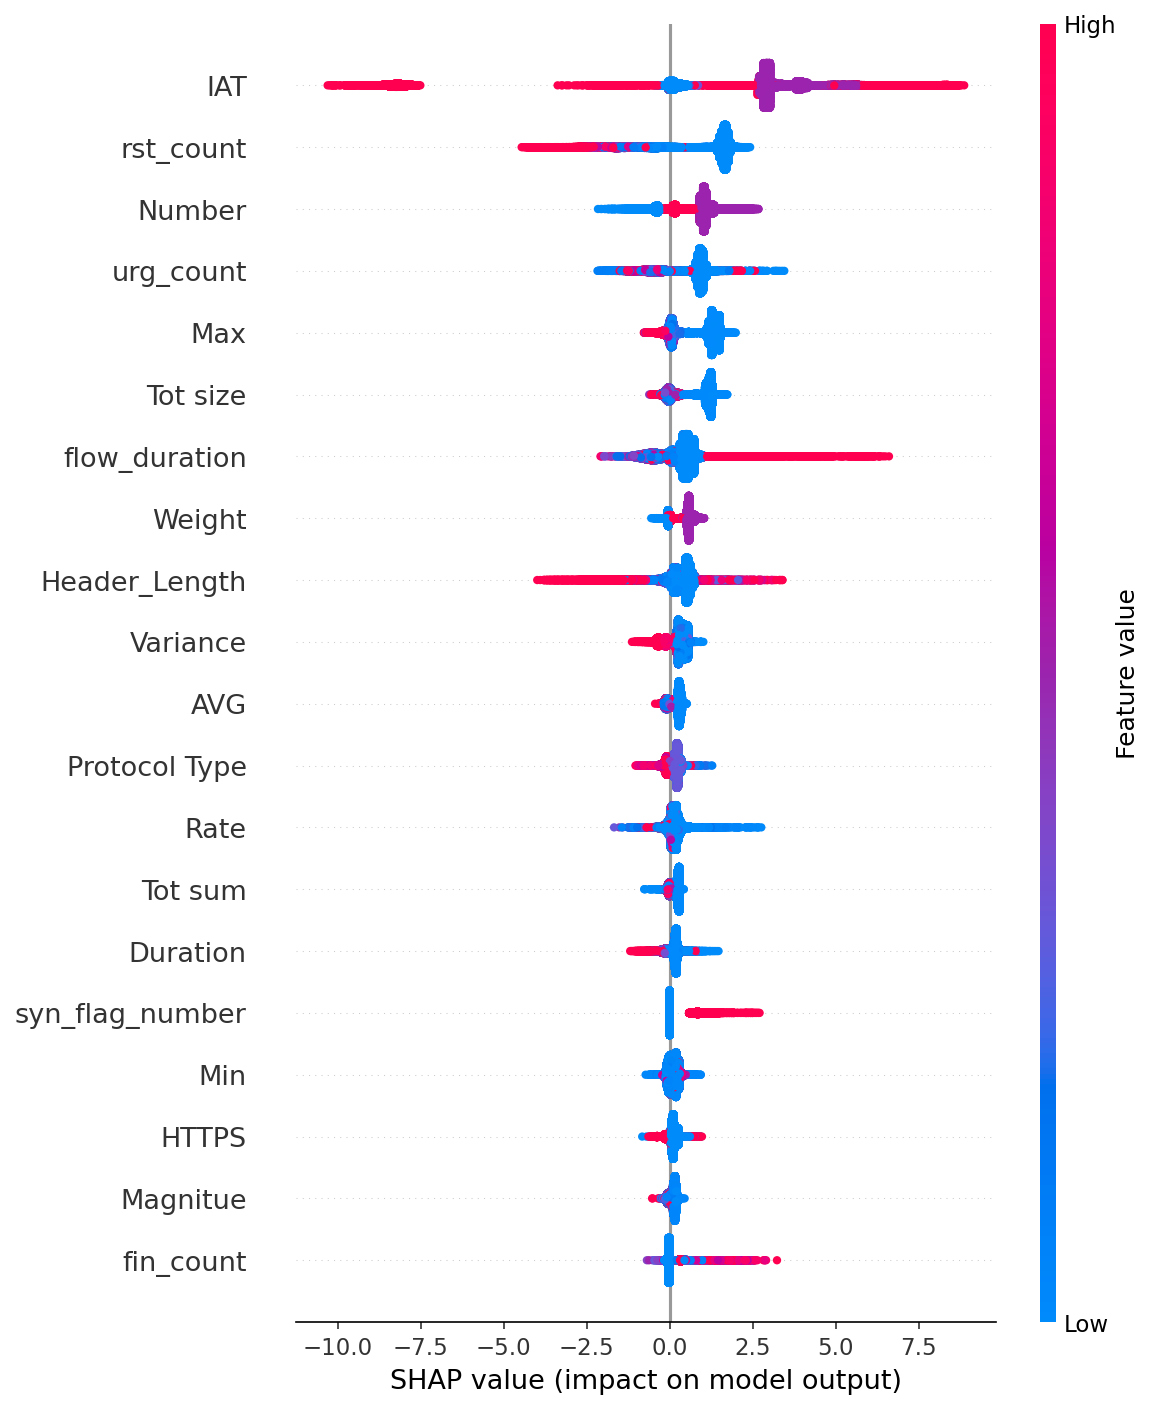

SHAP explanations were computed on a large calibration sample of 100,000 flows. The feature ranking was stable and showed that temporal and packet-control features dominate the XGBoost decision process, with IAT being the most influential feature, followed by reset count, packet count, urgent count, maximum packet statistics, total size, and flow duration.

## Step 14: XGBoost-Only Adversarial Phase

This phase is prepared for XGBoost only. It is enabled for the final run because ART
attacks and robust retraining can be expensive.

### 14.1 Configure XGBoost adversarial phase

In [109]:
# 14.1 Configure XGBoost adversarial phase
RUN_XGB_ADVERSARIAL_PHASE = True
XGB_ADV_SAMPLE_SIZE = 10_000
XGB_SURROGATE_TRAIN_SIZE = 1_000_000
XGB_ADV_TRAIN_ATTACK_SIZE = 5_000

XGB_CUSTOM_SHIFT = 0.40
XGB_CUSTOM_NOISE = 0.10
XGB_STRONG_SHIFT = 0.80
XGB_STRONG_NOISE = 0.15

xgb_adversarial_results = {}


### 14.2 Define XGBoost adversarial helpers

In [110]:
# 14.2 Define XGBoost adversarial helpers
def xgb_probabilities(model, X_eval):
    return model.predict_proba(X_eval)[:, 1]


def evaluate_xgb_attack_scenario(model, scenario, X_eval, y_eval, threshold):
    start = time.perf_counter()
    y_prob = xgb_probabilities(model, X_eval)
    inference_time = time.perf_counter() - start

    y_pred = (y_prob >= threshold).astype(np.int64)
    row = binary_metrics(y_eval, y_pred, y_prob)
    row = add_auc_metrics(row, y_eval, y_prob)
    row.update({
        "Model": "XGBoost",
        "Scenario": scenario,
        "Threshold": threshold,
        "Inference Time (s)": inference_time,
    })
    return row

### 14.3 Import ART for XGBoost attacks

In [111]:
# 14.3 Import ART for XGBoost attacks
if RUN_XGB_ADVERSARIAL_PHASE:
    try:
        from art.estimators.classification import PyTorchClassifier
        from art.estimators.classification import XGBoostClassifier as ArtXGBoostClassifier
        from art.attacks.evasion import HopSkipJump, ProjectedGradientDescent, ZooAttack

        XGB_ART_AVAILABLE = True
    except Exception as exc:
        print("ART is not available:", exc)



### 14.4 Wrap XGBoost for ART

In [112]:
# 14.4 Wrap XGBoost for ART
if RUN_XGB_ADVERSARIAL_PHASE and XGB_ART_AVAILABLE:
    xgb_art_classifier = ArtXGBoostClassifier(
        model=xgb_model,
        nb_features=X_fit_pool.shape[1],
        nb_classes=2,
    )
    print("XGBoost ART wrapper is ready.")

XGBoost ART wrapper is ready.


### 14.5 Select XGBoost true-positive attack rows

In [113]:
# 14.5 Select XGBoost true-positive attack rows
if RUN_XGB_ADVERSARIAL_PHASE:
    xgb_test_pred_for_adv = (xgb_selected_prob >= selected_threshold).astype(np.int64)
    xgb_tp_rows = np.where((y_test == 1) & (xgb_test_pred_for_adv == 1))[0]

    rng = np.random.default_rng(RANDOM_STATE)
    xgb_adv_n = min(XGB_ADV_SAMPLE_SIZE, len(xgb_tp_rows))
    xgb_adv_rows = rng.choice(xgb_tp_rows, size=xgb_adv_n, replace=False)

    X_xgb_attack_clean = X_test[xgb_adv_rows]
    y_xgb_attack_clean = y_test[xgb_adv_rows]
    print("XGBoost attack sample:", X_xgb_attack_clean.shape)

XGBoost attack sample: (10000, 46)


### 14.6 Save clean XGBoost adversarial baseline

In [114]:
# 14.6 Save clean XGBoost adversarial baseline
if RUN_XGB_ADVERSARIAL_PHASE:
    xgb_clean_adv_row = evaluate_xgb_attack_scenario(
        xgb_model, "Clean Test", X_test, y_test, selected_threshold
    )
    xgb_adversarial_results["XGBoost | Clean Test"] = xgb_clean_adv_row
    pd.DataFrame([xgb_clean_adv_row])

### 14.7 Generate ZOO examples for XGBoost

In [126]:
# 14.7 Generate ZOO examples for XGBoost
xgb_zoo_attack = ZooAttack(
    classifier=xgb_art_classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=30,
    binary_search_steps=1,
    initial_const=1e-2,
    abort_early=True,
    batch_size=1,
    nb_parallel=4,
)

X_xgb_zoo = xgb_zoo_attack.generate(x=X_xgb_attack_clean)
y_xgb_zoo_clean = y_xgb_attack_clean

xgb_zoo_ready = True

print("ZOO input:", X_xgb_attack_clean.shape)
print("XGBoost ZOO attack is ready:", X_xgb_zoo.shape)

ZOO:   0%|          | 0/10000 [00:00<?, ?it/s]

ZOO input: (10000, 46)
XGBoost ZOO attack is ready: (10000, 46)


### 14.8 Evaluate XGBoost on ZOO examples

In [ ]:
# 14.8 Evaluate XGBoost on ZOO examples
xgb_zoo_row = evaluate_xgb_attack_scenario(
    xgb_model,
    "ZOO Attack",
    X_xgb_zoo,
    y_xgb_zoo_clean,
    selected_threshold,
)

xgb_adversarial_results["XGBoost | ZOO Attack"] = xgb_zoo_row
pd.DataFrame([xgb_zoo_row])

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s)
0,0.9999,1.0,0.9999,0.99995,0.499975,0.9999,0.99995,0.0,0.01,0.0,0,0,1,9999,NaN,1.0,XGBoost,ZOO Attack,0.454,0.032978


In [127]:
# Check ZOO perturbation strength
zoo_diff = np.abs(X_xgb_zoo - X_xgb_attack_clean).mean()
zoo_max_diff = np.abs(X_xgb_zoo - X_xgb_attack_clean).max()

print("Mean absolute ZOO perturbation:", zoo_diff)
print("Max absolute ZOO perturbation:", zoo_max_diff)
print("ZOO samples:", X_xgb_zoo.shape)

Mean absolute ZOO perturbation: 7.5615108e-06
Max absolute ZOO perturbation: 0.2783065
ZOO samples: (10000, 46)


**Note on ZOO Attack Effectiveness**

ZOO was evaluated on 10,000 attack flows that were initially detected correctly by XGBoost. The attack had limited effect on the model, with only 1 out of 10,000 adversarial samples being missed.

This suggests that, under the tested configuration, ZOO produced limited changes in the tabular feature space and did not meaningfully alter the XGBoost decision paths. Since tree-based models rely on feature split thresholds, small perturbations may not be sufficient to cross decision boundaries.

Therefore, we treat the ZOO result as an additional robustness check with limited adversarial impact, and place greater emphasis on HopSkipJump, PGD transfer, and custom statistical evasion attacks.

### 14.9 Generate HopSkipJump examples for XGBoost

In [139]:
# 14.9 Generate HopSkipJump examples for XGBoost
XGB_HSJ_SAMPLE_SIZE = 5_000

xgb_hsj_n = min(XGB_HSJ_SAMPLE_SIZE, len(X_xgb_attack_clean))

hsj_rng = np.random.default_rng(RANDOM_STATE + 50)
hsj_rows = hsj_rng.choice(len(X_xgb_attack_clean), size=xgb_hsj_n, replace=False)

X_xgb_hsj_clean = X_xgb_attack_clean[hsj_rows].astype(np.float32)
y_xgb_hsj_clean = y_xgb_attack_clean[hsj_rows].astype(np.int64)

xgb_hsj_cache = results_dir / f"xgboost_only_hsj_aligned_{xgb_hsj_n}.npz"

if xgb_hsj_cache.exists():
    hsj_data = np.load(xgb_hsj_cache)
    X_xgb_hsj_clean = hsj_data["X_clean"]
    X_xgb_hsj = hsj_data["X_adv"]
    y_xgb_hsj_clean = hsj_data["y"]
    hsj_rows = hsj_data["source_rows"]
else:
    xgb_hsj_attack = HopSkipJump(
        classifier=xgb_art_classifier,
        targeted=False,
        max_iter=50,
        max_eval=1000,
        init_eval=100,
        init_size=100,
        norm=2,
        verbose=True,
    )

    X_xgb_hsj = xgb_hsj_attack.generate(x=X_xgb_hsj_clean)

    np.savez_compressed(
        xgb_hsj_cache,
        X_clean=X_xgb_hsj_clean,
        X_adv=X_xgb_hsj.astype(np.float32),
        y=y_xgb_hsj_clean,
        source_rows=hsj_rows,
    )

assert len(X_xgb_hsj) == len(y_xgb_hsj_clean)
assert len(X_xgb_hsj_clean) == len(y_xgb_hsj_clean)

xgb_hsj_ready = True

print("HSJ clean input:", X_xgb_hsj_clean.shape)
print("HSJ adversarial output:", X_xgb_hsj.shape)
print("HSJ labels:", y_xgb_hsj_clean.shape)
print("Saved/loaded:", xgb_hsj_cache)

HopSkipJump:   0%|          | 0/5000 [00:00<?, ?it/s]

HSJ clean input: (5000, 46)
HSJ adversarial output: (5000, 46)
HSJ labels: (5000,)
Saved/loaded: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_only_hsj_aligned_5000.npz


### 14.10 Evaluate XGBoost on HopSkipJump examples

In [140]:
# 14.10 Evaluate XGBoost on HopSkipJump examples
assert len(X_xgb_hsj) == len(y_xgb_hsj_clean)

xgb_hsj_row = evaluate_xgb_attack_scenario(
    xgb_model,
    "HopSkipJump Attack",
    X_xgb_hsj,
    y_xgb_hsj_clean,
    selected_threshold,
)

xgb_adversarial_results["XGBoost | HopSkipJump Attack"] = xgb_hsj_row

hsj_prob = xgb_model.predict_proba(X_xgb_hsj)[:, 1]
hsj_pred = (hsj_prob >= selected_threshold).astype(np.int64)

print("HSJ pred unique:", np.unique(hsj_pred, return_counts=True))
print("Probability min/mean/max:", hsj_prob.min(), hsj_prob.mean(), hsj_prob.max())

pd.DataFrame([xgb_hsj_row])

HSJ pred unique: (array([1]), array([5000]))
Probability min/mean/max: 0.50033563 0.9961451 0.9999999


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s)
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0,0,0,5000,NaN,1.0,XGBoost,HopSkipJump Attack,0.454,0.006608


HSJ failed to evade the selected XGBoost binary gate under the tested configuration. All 5,000 adversarial attack samples remained above the operational threshold 0.454, with the minimum attack probability still equal to 0.5003.

HopSkipJump was evaluated on 5,000 attack flows that were initially correctly detected by the selected XGBoost binary gate. After the attack, all samples remained above the operational threshold of 0.454, with the minimum attack probability equal to 0.5003. Therefore, no attack sample was misclassified as benign under this configuration, resulting in 0% attack miss rate on the evaluated attack-only subset.

### 14.11 Train surrogate MLP for PGD transfer

In [160]:
# 14.11 Train a small surrogate MLP for PGD transfer
surrogate_n = min(XGB_SURROGATE_TRAIN_SIZE, len(X_fit_pool))

rng = np.random.default_rng(RANDOM_STATE + 10)
surrogate_rows = rng.choice(len(X_fit_pool), size=surrogate_n, replace=False)

X_xgb_surrogate = X_fit_pool[surrogate_rows]

y_xgb_surrogate = (
    xgb_model.predict_proba(X_xgb_surrogate)[:, 1] >= selected_threshold
).astype(np.int64)

xgb_surrogate = BinaryMLP(
    X_fit_pool.shape[1],
    [128, 64],
    0.2,
).to(device)

xgb_surrogate_loader = make_loader(
    X_xgb_surrogate,
    y_xgb_surrogate,
    batch_size=2048,
    shuffle=True,
)

xgb_surrogate_loss = torch.nn.CrossEntropyLoss()
xgb_surrogate_optimizer = torch.optim.Adam(
    xgb_surrogate.parameters(),
    lr=1e-3,
)

for epoch in range(15):
    train_one_mlp_epoch(
        xgb_surrogate,
        xgb_surrogate_loader,
        xgb_surrogate_loss,
        xgb_surrogate_optimizer,
    )

xgb_surrogate.eval()

print("Surrogate rows:", X_xgb_surrogate.shape)
print("XGBoost surrogate MLP trained.")

Surrogate rows: (1000000, 46)
XGBoost surrogate MLP trained.


#### 14.11b Check surrogate agreement


In [161]:
# Check surrogate agreement with XGBoost labels
surrogate_prob = mlp_predict_proba(
    xgb_surrogate,
    X_xgb_surrogate[:100_000],
    batch_size=2048,
)

surrogate_pred = (surrogate_prob >= 0.5).astype(np.int64)
xgb_pseudo_sample = y_xgb_surrogate[:100_000]

surrogate_agreement = (surrogate_pred == xgb_pseudo_sample).mean()

print("Surrogate agreement with XGBoost pseudo-labels:", surrogate_agreement)

Surrogate agreement with XGBoost pseudo-labels: 0.97251


### 14.12 Generate PGD transfer examples for XGBoost

In [162]:
# 14.12 Rebuild aligned PGD attack sample
XGB_PGD_SAMPLE_SIZE = 10_000

xgb_test_pred_for_pgd = (xgb_selected_prob >= selected_threshold).astype(np.int64)
xgb_pgd_tp_rows = np.where((y_test == 1) & (xgb_test_pred_for_pgd == 1))[0]

pgd_rng = np.random.default_rng(RANDOM_STATE + 60)
xgb_pgd_n = min(XGB_PGD_SAMPLE_SIZE, len(xgb_pgd_tp_rows))
xgb_pgd_rows = pgd_rng.choice(xgb_pgd_tp_rows, size=xgb_pgd_n, replace=False)

X_xgb_pgd_clean = X_test[xgb_pgd_rows].astype(np.float32)
y_xgb_pgd_clean = y_test[xgb_pgd_rows].astype(np.int64)

print("PGD clean input:", X_xgb_pgd_clean.shape)
print("PGD labels:", y_xgb_pgd_clean.shape)
print("Unique labels:", np.unique(y_xgb_pgd_clean, return_counts=True))

PGD clean input: (10000, 46)
PGD labels: (10000,)
Unique labels: (array([1]), array([10000]))


In [163]:
# 14.12 Generate PGD transfer examples for XGBoost
xgb_pgd_cache = results_dir / f"xgboost_only_pgd_aligned_{xgb_pgd_n}_eps05_iter60.npz"

print("Cache path:", xgb_pgd_cache)
print("Cache exists before run:", xgb_pgd_cache.exists())

start = time.perf_counter()

if xgb_pgd_cache.exists():
    pgd_data = np.load(xgb_pgd_cache)
    X_xgb_pgd_clean = pgd_data["X_clean"]
    X_xgb_pgd = pgd_data["X_adv"]
    y_xgb_pgd_clean = pgd_data["y"]
    xgb_pgd_rows = pgd_data["source_rows"]
    pgd_source = "loaded_from_cache"
else:
    xgb_art_surrogate = PyTorchClassifier(
        model=xgb_surrogate,
        loss=xgb_surrogate_loss,
        input_shape=(X_fit_pool.shape[1],),
        nb_classes=2,
        optimizer=xgb_surrogate_optimizer,
        device_type="gpu" if device.type == "cuda" else "cpu",
    )

    xgb_pgd_attack = ProjectedGradientDescent(
        estimator=xgb_art_surrogate,
        eps=0.5,
        eps_step=0.05,
        max_iter=60,
        targeted=False,
        num_random_init=5,
        batch_size=256,
        verbose=True,
    )

    X_xgb_pgd = xgb_pgd_attack.generate(x=X_xgb_pgd_clean)

    np.savez_compressed(
        xgb_pgd_cache,
        X_clean=X_xgb_pgd_clean,
        X_adv=X_xgb_pgd.astype(np.float32),
        y=y_xgb_pgd_clean,
        source_rows=xgb_pgd_rows,
    )

    pgd_source = "generated_new"

pgd_time = time.perf_counter() - start

assert len(X_xgb_pgd) == len(y_xgb_pgd_clean)
assert len(X_xgb_pgd_clean) == len(y_xgb_pgd_clean)

pgd_diff = X_xgb_pgd - X_xgb_pgd_clean
pgd_abs_diff = np.abs(pgd_diff)

print("PGD source:", pgd_source)
print("PGD time (s):", pgd_time)
print("PGD clean input:", X_xgb_pgd_clean.shape)
print("PGD adversarial output:", X_xgb_pgd.shape)
print("PGD labels:", y_xgb_pgd_clean.shape)
print("Mean abs perturbation:", pgd_abs_diff.mean())
print("Max abs perturbation:", pgd_abs_diff.max())
print("Changed values:", np.count_nonzero(pgd_abs_diff > 1e-8))
print("Changed rows:", np.count_nonzero(np.linalg.norm(pgd_diff, axis=1) > 1e-8))

xgb_pgd_ready = True

Cache path: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_only_pgd_aligned_10000_eps05_iter60.npz
Cache exists before run: False


PGD - Batches:   0%|          | 0/40 [00:00<?, ?it/s]

PGD source: generated_new
PGD time (s): 17.213025199991534
PGD clean input: (10000, 46)
PGD adversarial output: (10000, 46)
PGD labels: (10000,)
Mean abs perturbation: 0.47980034
Max abs perturbation: 0.50001526
Changed values: 459993
Changed rows: 10000


### 14.13 Evaluate XGBoost on PGD transfer examples

In [165]:
# 14.13 Evaluate XGBoost on PGD transfer examples
assert len(X_xgb_pgd) == len(y_xgb_pgd_clean)

xgb_pgd_row = evaluate_xgb_attack_scenario(
    xgb_model,
    "Surrogate PGD Attack",
    X_xgb_pgd,
    y_xgb_pgd_clean,
    selected_threshold,
)

xgb_adversarial_results["XGBoost | Surrogate PGD Attack"] = xgb_pgd_row

pgd_prob = xgb_model.predict_proba(X_xgb_pgd)[:, 1]
pgd_pred = (pgd_prob >= selected_threshold).astype(np.int64)

print("PGD pred unique:", np.unique(pgd_pred, return_counts=True))
print("Probability min/mean/max:", pgd_prob.min(), pgd_prob.mean(), pgd_prob.max())

pd.DataFrame([xgb_pgd_row])

PGD pred unique: (array([0, 1]), array([   8, 9992]))
Probability min/mean/max: 0.15199764 0.99830604 0.9999994


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s)
0,0.9992,1.0,0.9992,0.9996,0.4998,0.9992,0.9996,0.0,0.08,0.0,0,0,8,9992,NaN,1.0,XGBoost,Surrogate PGD Attack,0.454,0.038584


The PGD transfer attack was generated using a surrogate MLP trained to imitate the XGBoost binary gate. The surrogate agreement with XGBoost pseudo-labels was checked before generating PGD. Under a strong perturbation budget (`eps=0.5`), the attack is evaluated on aligned attack-only samples. The key metric is the number of attack samples pushed below the operational threshold `0.454`, i.e., the resulting false negatives.

The PGD transfer attack was generated using a surrogate MLP trained to imitate the XGBoost binary gate, achieving 97.2% agreement with XGBoost pseudo-labels. Under a strong perturbation budget (eps=0.5), PGD changed all 10,000 evaluated attack samples, but only 8 samples were misclassified as benign by XGBoost. This corresponds to a 0.08% attack miss rate, indicating limited transferability of the surrogate-based PGD attack to the selected XGBoost model.

XGBoost resisted the surrogate PGD transfer attack with only 0.08% evasion success.
robust under the tested PGD transfer setting

### 14.14 Define custom statistical attack


In [166]:
# 14.14 Define custom statistical attack
def make_xgb_custom_shift_attack(X, y, benign_mean_vector, shift_intensity, noise_scale):
    X_adv = np.array(X, copy=True)
    attack_rows = np.where(y == 1)[0]

    shift = benign_mean_vector - X_adv[attack_rows]
    X_adv[attack_rows] = X_adv[attack_rows] + shift_intensity * shift

    rng = np.random.default_rng(RANDOM_STATE)
    noise = rng.normal(
        loc=0.0,
        scale=noise_scale,
        size=X_adv[attack_rows].shape,
    )

    X_adv[attack_rows] = X_adv[attack_rows] + noise
    return X_adv.astype(np.float32)

### 14.15 Evaluate custom attacks on XGBoost


In [167]:
# 14.15 Evaluate custom attacks on XGBoost
xgb_benign_mean_vector = X_fit_pool[y_fit_pool == 0].mean(axis=0)

X_xgb_custom = make_xgb_custom_shift_attack(
    X_test,
    y_test,
    xgb_benign_mean_vector,
    XGB_CUSTOM_SHIFT,
    XGB_CUSTOM_NOISE,
)

X_xgb_strong = make_xgb_custom_shift_attack(
    X_test,
    y_test,
    xgb_benign_mean_vector,
    XGB_STRONG_SHIFT,
    XGB_STRONG_NOISE,
)

xgb_custom_row = evaluate_xgb_attack_scenario(
    xgb_model,
    "Custom Shift 0.4",
    X_xgb_custom,
    y_test,
    selected_threshold,
)

xgb_strong_row = evaluate_xgb_attack_scenario(
    xgb_model,
    "Custom Shift 0.8",
    X_xgb_strong,
    y_test,
    selected_threshold,
)

xgb_adversarial_results["XGBoost | Custom Shift 0.4"] = xgb_custom_row
xgb_adversarial_results["XGBoost | Custom Shift 0.8"] = xgb_strong_row

pd.DataFrame([xgb_custom_row, xgb_strong_row])

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s)
0,0.995267,0.994469,0.999948,0.997201,0.990945,0.995267,0.995238,0.982046,0.005168,2.988996,213074,6565,61,1180299,0.999963,0.999993,XGBoost,Custom Shift 0.4,0.454,0.673345
1,0.995213,0.994468,0.999884,0.997169,0.990843,0.995213,0.995184,0.981838,0.011607,2.988996,213074,6565,137,1180223,0.999894,0.999980,XGBoost,Custom Shift 0.8,0.454,0.587497


### 14.16 Save XGBoost adversarial results


In [168]:
# 14.16 Save XGBoost adversarial results
xgb_adversarial_df = pd.DataFrame(xgb_adversarial_results.values())
xgb_adversarial_df.to_csv(
    results_dir / "xgboost_only_adversarial_results.csv",
    index=False,
)

xgb_adversarial_df

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),TN,FP,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s)
0,0.988463,0.994424,0.991878,0.993149,0.978316,0.988463,0.988495,0.956663,0.812210,2.988996,213074,6565,9587,1170773,0.999024,0.999822,XGBoost,Clean Test,0.454,0.662336
1,0.999900,1.000000,0.999900,0.999950,0.499975,0.999900,0.999950,0.000000,0.010000,0.000000,0,0,1,9999,NaN,1.000000,XGBoost,ZOO Attack,0.454,0.032978
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0,0,0,5000,NaN,1.000000,XGBoost,HopSkipJump Attack,0.454,0.006608
3,0.999200,1.000000,0.999200,0.999600,0.499800,0.999200,0.999600,0.000000,0.080000,0.000000,0,0,8,9992,NaN,1.000000,XGBoost,Surrogate PGD Attack,0.454,0.038584
4,0.995267,0.994469,0.999948,0.997201,0.990945,0.995267,0.995238,0.982046,0.005168,2.988996,213074,6565,61,1180299,0.999963,0.999993,XGBoost,Custom Shift 0.4,0.454,0.673345
5,0.995213,0.994468,0.999884,0.997169,0.990843,0.995213,0.995184,0.981838,0.011607,2.988996,213074,6565,137,1180223,0.999894,0.999980,XGBoost,Custom Shift 0.8,0.454,0.587497


### 14.17 Save perturbation summary


In [169]:
# 14.17 Save perturbation summary
perturbation_rows = []

if "X_xgb_zoo" in globals() and len(X_xgb_zoo) == len(X_xgb_attack_clean):
    diff = np.abs(X_xgb_zoo - X_xgb_attack_clean)
    perturbation_rows.append({
        "Attack": "ZOO",
        "Samples": len(X_xgb_zoo),
        "Mean Absolute Perturbation": float(diff.mean()),
        "Max Absolute Perturbation": float(diff.max()),
        "Changed Rows": int((diff.sum(axis=1) > 0).sum()),
    })

if "X_xgb_hsj" in globals() and "X_xgb_hsj_clean" in globals():
    diff = np.abs(X_xgb_hsj - X_xgb_hsj_clean)
    perturbation_rows.append({
        "Attack": "HopSkipJump",
        "Samples": len(X_xgb_hsj),
        "Mean Absolute Perturbation": float(diff.mean()),
        "Max Absolute Perturbation": float(diff.max()),
        "Changed Rows": int((diff.sum(axis=1) > 0).sum()),
    })

if "X_xgb_pgd" in globals() and "X_xgb_pgd_clean" in globals():
    diff = np.abs(X_xgb_pgd - X_xgb_pgd_clean)
    perturbation_rows.append({
        "Attack": "Surrogate PGD",
        "Samples": len(X_xgb_pgd),
        "Mean Absolute Perturbation": float(diff.mean()),
        "Max Absolute Perturbation": float(diff.max()),
        "Changed Rows": int((diff.sum(axis=1) > 0).sum()),
    })

diff = np.abs(X_xgb_custom - X_test)
perturbation_rows.append({
    "Attack": "Custom Shift 0.4",
    "Samples": len(X_xgb_custom),
    "Mean Absolute Perturbation": float(diff.mean()),
    "Max Absolute Perturbation": float(diff.max()),
    "Changed Rows": int((diff.sum(axis=1) > 0).sum()),
})

diff = np.abs(X_xgb_strong - X_test)
perturbation_rows.append({
    "Attack": "Custom Shift 0.8",
    "Samples": len(X_xgb_strong),
    "Mean Absolute Perturbation": float(diff.mean()),
    "Max Absolute Perturbation": float(diff.max()),
    "Changed Rows": int((diff.sum(axis=1) > 0).sum()),
})

xgb_perturbation_df = pd.DataFrame(perturbation_rows)
xgb_perturbation_df.to_csv(
    results_dir / "xgboost_adversarial_perturbation_summary.csv",
    index=False,
)

xgb_perturbation_df

,Attack,Samples,Mean Absolute Perturbation,Max Absolute Perturbation,Changed Rows
0,HopSkipJump,5000,8.035204e-11,0.000001,5
1,Surrogate PGD,10000,4.798003e-01,0.500015,10000
2,Custom Shift 0.4,1399999,1.288051e+01,40543.093750,1180360
3,Custom Shift 0.8,1399999,2.574427e+01,81086.117188,1180360


## Step 14 Completion: Cleaned Adversarial Reporting

These cells finalize the XGBoost adversarial reporting after the raw adversarial results have been saved.

They rebuild the corrected perturbation summary, create a cleaned attack-only/full-test report, and save phase notes for the paper update.


### 14.17b Rebuild corrected perturbation summary

This cell rebuilds the perturbation summary using explicit clean/adversarial pairs. It fixes the case where ZOO may be missing from the previous perturbation table.

In [187]:
# 14.17b Rebuild corrected perturbation summary
if "xgb_adv_rows" in globals() and len(xgb_adv_rows) == len(X_xgb_zoo):
    X_xgb_zoo_clean = X_test[xgb_adv_rows].astype(np.float32)
else:
    xgb_zoo_pred_for_adv = (xgb_selected_prob >= selected_threshold).astype(np.int64)
    xgb_zoo_tp_rows = np.where((y_test == 1) & (xgb_zoo_pred_for_adv == 1))[0]

    zoo_rng = np.random.default_rng(RANDOM_STATE)
    xgb_zoo_rows = zoo_rng.choice(
        xgb_zoo_tp_rows,
        size=len(X_xgb_zoo),
        replace=False,
    )

    X_xgb_zoo_clean = X_test[xgb_zoo_rows].astype(np.float32)

perturbation_rows = []

assert len(X_xgb_zoo) == len(X_xgb_zoo_clean)

zoo_diff = np.abs(X_xgb_zoo - X_xgb_zoo_clean)
perturbation_rows.append({
    "Attack": "ZOO",
    "Samples": len(X_xgb_zoo),
    "Mean Absolute Perturbation": float(zoo_diff.mean()),
    "Max Absolute Perturbation": float(zoo_diff.max()),
    "Changed Rows": int((zoo_diff.sum(axis=1) > 1e-8).sum()),
})

hsj_diff = np.abs(X_xgb_hsj - X_xgb_hsj_clean)
perturbation_rows.append({
    "Attack": "HopSkipJump",
    "Samples": len(X_xgb_hsj),
    "Mean Absolute Perturbation": float(hsj_diff.mean()),
    "Max Absolute Perturbation": float(hsj_diff.max()),
    "Changed Rows": int((hsj_diff.sum(axis=1) > 1e-8).sum()),
})

pgd_diff = np.abs(X_xgb_pgd - X_xgb_pgd_clean)
perturbation_rows.append({
    "Attack": "Surrogate PGD",
    "Samples": len(X_xgb_pgd),
    "Mean Absolute Perturbation": float(pgd_diff.mean()),
    "Max Absolute Perturbation": float(pgd_diff.max()),
    "Changed Rows": int((pgd_diff.sum(axis=1) > 1e-8).sum()),
})

custom_diff = np.abs(X_xgb_custom - X_test)
perturbation_rows.append({
    "Attack": "Custom Shift 0.4",
    "Samples": len(X_xgb_custom),
    "Mean Absolute Perturbation": float(custom_diff.mean()),
    "Max Absolute Perturbation": float(custom_diff.max()),
    "Changed Rows": int((custom_diff.sum(axis=1) > 1e-8).sum()),
})

strong_diff = np.abs(X_xgb_strong - X_test)
perturbation_rows.append({
    "Attack": "Custom Shift 0.8",
    "Samples": len(X_xgb_strong),
    "Mean Absolute Perturbation": float(strong_diff.mean()),
    "Max Absolute Perturbation": float(strong_diff.max()),
    "Changed Rows": int((strong_diff.sum(axis=1) > 1e-8).sum()),
})

xgb_perturbation_df = pd.DataFrame(perturbation_rows)
xgb_perturbation_df.to_csv(
    results_dir / "xgboost_adversarial_perturbation_summary_corrected.csv",
    index=False,
)

xgb_perturbation_df

,Attack,Samples,Mean Absolute Perturbation,Max Absolute Perturbation,Changed Rows
0,ZOO,10000,7.561511e-06,0.278307,12
1,HopSkipJump,5000,8.035204e-11,0.000001,5
2,Surrogate PGD,10000,4.798003e-01,0.500015,10000
3,Custom Shift 0.4,1399999,1.288051e+01,40543.093750,1180360
4,Custom Shift 0.8,1399999,2.574427e+01,81086.117188,1180360


### 14.18 Build cleaned adversarial report

Attack-only scenarios contain only malicious flows. For these rows, some metrics are not meaningful, so we keep the security metrics and blank the misleading metrics.

In [188]:
# 14.18 Build cleaned adversarial report
xgb_adversarial_cleaned_df = xgb_adversarial_df.copy()

attack_only_scenarios = [
    "ZOO Attack",
    "HopSkipJump Attack",
    "Surrogate PGD Attack",
]

xgb_adversarial_cleaned_df["Samples"] = (
    xgb_adversarial_cleaned_df["TN"]
    + xgb_adversarial_cleaned_df["FP"]
    + xgb_adversarial_cleaned_df["FN"]
    + xgb_adversarial_cleaned_df["TP"]
)

xgb_adversarial_cleaned_df["Evaluation Type"] = "Full test"
xgb_adversarial_cleaned_df.loc[
    xgb_adversarial_cleaned_df["Scenario"].isin(attack_only_scenarios),
    "Evaluation Type",
] = "Attack-only"

misleading_columns = [
    "F1-Macro",
    "F1-Weighted",
    "MCC",
    "False Alarm Rate (%)",
    "ROC-AUC",
    "PR-AUC",
]

attack_only_mask = xgb_adversarial_cleaned_df["Evaluation Type"] == "Attack-only"
xgb_adversarial_cleaned_df.loc[attack_only_mask, misleading_columns] = np.nan

xgb_adversarial_cleaned_df.to_csv(
    results_dir / "xgboost_only_adversarial_results_cleaned.csv",
    index=False,
)

xgb_adversarial_cleaned_df

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Samples,Evaluation Type
0,0.988463,0.994424,0.991878,0.993149,0.978316,0.988463,0.988495,0.956663,0.812210,2.988996,...,9587,1170773,0.999024,0.999822,XGBoost,Clean Test,0.454,0.662336,1399999,Full test
1,0.999900,1.000000,0.999900,0.999950,NaN,0.999900,NaN,NaN,0.010000,NaN,...,1,9999,NaN,NaN,XGBoost,ZOO Attack,0.454,0.032978,10000,Attack-only
2,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,NaN,0.000000,NaN,...,0,5000,NaN,NaN,XGBoost,HopSkipJump Attack,0.454,0.006608,5000,Attack-only
3,0.999200,1.000000,0.999200,0.999600,NaN,0.999200,NaN,NaN,0.080000,NaN,...,8,9992,NaN,NaN,XGBoost,Surrogate PGD Attack,0.454,0.038584,10000,Attack-only
4,0.995267,0.994469,0.999948,0.997201,0.990945,0.995267,0.995238,0.982046,0.005168,2.988996,...,61,1180299,0.999963,0.999993,XGBoost,Custom Shift 0.4,0.454,0.673345,1399999,Full test
5,0.995213,0.994468,0.999884,0.997169,0.990843,0.995213,0.995184,0.981838,0.011607,2.988996,...,137,1180223,0.999894,0.999980,XGBoost,Custom Shift 0.8,0.454,0.587497,1399999,Full test


### 14.19 Save internal adversarial miss-rate diagnostic plot

This plot is kept as an internal diagnostic only because it places full-test and attack-only scenarios on one axis. For paper/reporting use, rely on the separated full-test and attack-only plots saved in Step 16.


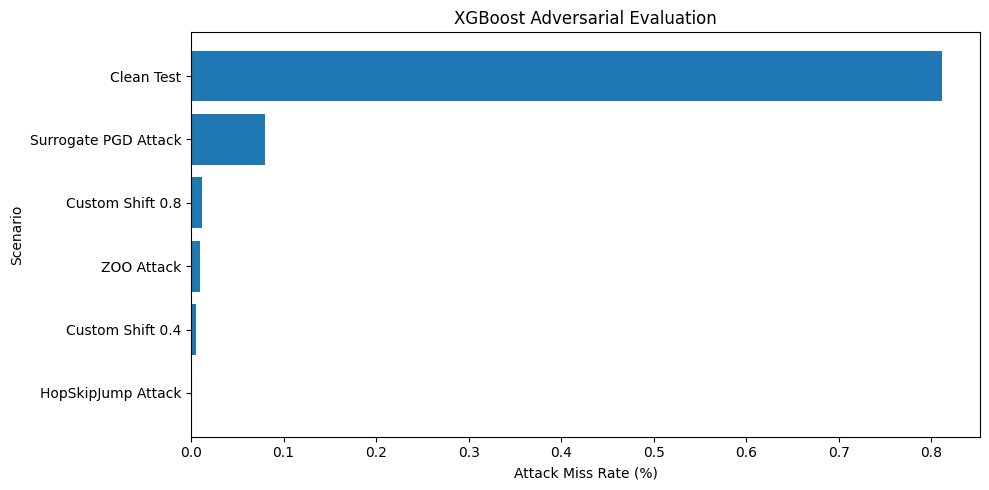

In [189]:
# 14.19 Save internal adversarial miss-rate diagnostic plot
plot_df = xgb_adversarial_cleaned_df.sort_values(
    "Attack Miss Rate (%)",
    ascending=False,
)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["Scenario"], plot_df["Attack Miss Rate (%)"])
plt.xlabel("Attack Miss Rate (%)")
plt.ylabel("Scenario")
plt.title("XGBoost Adversarial Evaluation")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    results_dir / "xgboost_adversarial_miss_rate.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 14.20 Save adversarial phase notes

This small JSON file documents the operational threshold, attack sizes, and caveats. It is useful when updating the paper.

In [190]:
# 14.20 Save adversarial phase notes
xgb_adversarial_phase_notes = {
    "selected_model": "XGBoost",
    "selected_threshold": float(selected_threshold),
    "threshold_reason": selected_threshold_reason,
    "zoo_samples": int(len(X_xgb_zoo)),
    "hsj_samples": int(len(X_xgb_hsj)),
    "pgd_samples": int(len(X_xgb_pgd)),
    "custom_shift_samples": int(len(X_test)),
    "surrogate_training_rows": int(len(X_xgb_surrogate)),
    "surrogate_agreement": float(surrogate_agreement),
    "attack_only_scenarios": attack_only_scenarios,
    "main_security_metric": "Attack Miss Rate (%)",
    "note": (
        "F1-Macro, F1-Weighted, MCC, ROC-AUC, PR-AUC, and FAR are not reported "
        "for attack-only scenarios because no benign class is present."
    ),
}

notes_path = results_dir / "xgboost_adversarial_phase_notes.json"

with open(notes_path, "w", encoding="utf-8") as f:
    json.dump(xgb_adversarial_phase_notes, f, indent=2)

xgb_adversarial_phase_notes

{'selected_model': 'XGBoost',
 'selected_threshold': 0.454,
 'threshold_reason': 'security_aggressive_low_fn_threshold',
 'zoo_samples': 10000,
 'hsj_samples': 5000,
 'pgd_samples': 10000,
 'custom_shift_samples': 1399999,
 'surrogate_training_rows': 1000000,
 'surrogate_agreement': 0.97251,
 'attack_only_scenarios': ['ZOO Attack',
  'HopSkipJump Attack',
  'Surrogate PGD Attack'],
 'main_security_metric': 'Attack Miss Rate (%)',
 'note': 'F1-Macro, F1-Weighted, MCC, ROC-AUC, PR-AUC, and FAR are not reported for attack-only scenarios because no benign class is present.'}

## Step 15: Multi-Adversarial Robust XGBoost

Run this step only if the paper keeps the claim that a hardened/adversarially trained binary XGBoost model was produced. All robust-training samples below are generated from `X_fit_pool/y_fit_pool`, not from test data.

### 15.1 Select training-only attack rows

In [191]:
# 15.1 Select training-only attack rows
XGB_ROBUST_TRAIN_ATTACK_SIZE = XGB_ADV_TRAIN_ATTACK_SIZE

fit_attack_rows = np.where(y_fit_pool == 1)[0]

robust_rng = np.random.default_rng(RANDOM_STATE + 70)
robust_rows = robust_rng.choice(
    fit_attack_rows,
    size=min(XGB_ROBUST_TRAIN_ATTACK_SIZE, len(fit_attack_rows)),
    replace=False,
)

X_robust_attack_clean = X_fit_pool[robust_rows].astype(np.float32)
y_robust_attack_clean = y_fit_pool[robust_rows].astype(np.int64)

robust_seed_prob = xgb_model.predict_proba(X_robust_attack_clean)[:, 1]
robust_keep = robust_seed_prob >= selected_threshold

X_robust_attack_clean = X_robust_attack_clean[robust_keep]
y_robust_attack_clean = y_robust_attack_clean[robust_keep]

print("Robust clean attack rows:", X_robust_attack_clean.shape)
print("Robust clean labels:", np.unique(y_robust_attack_clean, return_counts=True))

Robust clean attack rows: (4965, 46)
Robust clean labels: (array([1]), array([4965]))


### 15.2 Generate custom robust-training samples

In [192]:
# 15.2 Generate custom robust-training samples
X_robust_custom = make_xgb_custom_shift_attack(
    X_robust_attack_clean,
    y_robust_attack_clean,
    xgb_benign_mean_vector,
    XGB_CUSTOM_SHIFT,
    XGB_CUSTOM_NOISE,
)

print("Custom robust samples:", X_robust_custom.shape)

Custom robust samples: (4965, 46)


### 15.3 Generate HSJ robust-training samples

In [193]:
# 15.3 Generate HSJ robust-training samples
XGB_ROBUST_HSJ_SIZE = min(1_000, len(X_robust_attack_clean))

X_robust_hsj_clean = X_robust_attack_clean[:XGB_ROBUST_HSJ_SIZE]
y_robust_hsj_clean = y_robust_attack_clean[:XGB_ROBUST_HSJ_SIZE]

robust_hsj_cache = results_dir / f"xgboost_robust_train_hsj_{XGB_ROBUST_HSJ_SIZE}.npz"

if robust_hsj_cache.exists():
    hsj_train_data = np.load(robust_hsj_cache)
    X_robust_hsj = hsj_train_data["X_adv"]
    y_robust_hsj_clean = hsj_train_data["y"]
else:
    robust_hsj_attack = HopSkipJump(
        classifier=xgb_art_classifier,
        targeted=False,
        max_iter=50,
        max_eval=1000,
        init_eval=100,
        init_size=100,
        norm=2,
        verbose=True,
    )

    X_robust_hsj = robust_hsj_attack.generate(x=X_robust_hsj_clean)

    np.savez_compressed(
        robust_hsj_cache,
        X_clean=X_robust_hsj_clean,
        X_adv=X_robust_hsj.astype(np.float32),
        y=y_robust_hsj_clean,
    )

print("HSJ robust samples:", X_robust_hsj.shape)

HSJ robust samples: (1000, 46)


### 15.4 Generate PGD robust-training samples

In [194]:
# 15.4 Generate PGD robust-training samples
XGB_ROBUST_PGD_SIZE = min(XGB_ADV_TRAIN_ATTACK_SIZE, len(X_robust_attack_clean))

X_robust_pgd_clean = X_robust_attack_clean[:XGB_ROBUST_PGD_SIZE]
y_robust_pgd_clean = y_robust_attack_clean[:XGB_ROBUST_PGD_SIZE]

robust_pgd_cache = results_dir / f"xgboost_robust_train_pgd_{XGB_ROBUST_PGD_SIZE}_eps05_iter60.npz"

xgb_art_surrogate = PyTorchClassifier(
    model=xgb_surrogate,
    loss=xgb_surrogate_loss,
    input_shape=(X_fit_pool.shape[1],),
    nb_classes=2,
    optimizer=xgb_surrogate_optimizer,
    device_type="gpu" if device.type == "cuda" else "cpu",
)

if robust_pgd_cache.exists():
    pgd_train_data = np.load(robust_pgd_cache)
    X_robust_pgd = pgd_train_data["X_adv"]
    y_robust_pgd_clean = pgd_train_data["y"]
else:
    robust_pgd_attack = ProjectedGradientDescent(
        estimator=xgb_art_surrogate,
        eps=0.5,
        eps_step=0.05,
        max_iter=60,
        targeted=False,
        num_random_init=5,
        batch_size=256,
        verbose=True,
    )

    X_robust_pgd = robust_pgd_attack.generate(
        x=X_robust_pgd_clean.astype(np.float32)
    )

    np.savez_compressed(
        robust_pgd_cache,
        X_clean=X_robust_pgd_clean,
        X_adv=X_robust_pgd.astype(np.float32),
        y=y_robust_pgd_clean,
    )

print("PGD robust samples:", X_robust_pgd.shape)

PGD robust samples: (4965, 46)


### 15.5 Build augmented robust training data

The adversarial samples are up-weighted during fitting instead of being heavily duplicated. This keeps memory lower while still forcing the model to care about them.

In [195]:
# 15.5 Build augmented robust training data
X_robust_train = np.vstack([
    X_fit_pool.astype(np.float32),
    X_robust_custom.astype(np.float32),
    X_robust_hsj.astype(np.float32),
    X_robust_pgd.astype(np.float32),
])

y_robust_train = np.concatenate([
    y_fit_pool.astype(np.int64),
    y_robust_attack_clean.astype(np.int64),
    y_robust_hsj_clean.astype(np.int64),
    y_robust_pgd_clean.astype(np.int64),
])

robust_sample_weight = np.ones(len(y_robust_train), dtype=np.float32)
robust_sample_weight[len(y_fit_pool):] = 10.0

print("Fit pool:", X_fit_pool.shape)
print("Robust training data:", X_robust_train.shape)
print("Robust labels:", np.unique(y_robust_train, return_counts=True))
print("Adversarial sample weight:", robust_sample_weight[len(y_fit_pool)])

Fit pool: (4759994, 46)
Robust training data: (4770924, 46)
Robust labels: (array([0, 1]), array([ 746772, 4024152]))
Adversarial sample weight: 10.0


### 15.6 Train robust XGBoost

In [196]:
# 15.6 Train robust XGBoost
robust_xgb_params = xgb_params.copy()

robust_xgb_params.update({
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "device": xgb_params.get("device", xgb_device),
    "random_state": RANDOM_STATE,
    "n_jobs": 5,
})

xgb_robust_model = xgb.XGBClassifier(**robust_xgb_params)

start = time.perf_counter()
xgb_robust_model.fit(
    X_robust_train,
    y_robust_train,
    sample_weight=robust_sample_weight,
)
robust_training_time = time.perf_counter() - start

robust_model_path = models_dir / "xgboost_multi_adversarial_robust.joblib"
joblib.dump(xgb_robust_model, robust_model_path)

print("Robust XGBoost training time:", robust_training_time)
print("Saved robust model:", robust_model_path)

Robust XGBoost training time: 14.143406200004392
Saved robust model: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\models\reviewer3_binary\xgboost_multi_adversarial_robust.joblib


### 15.7 Calibrate robust XGBoost threshold

In [197]:
# 15.7 Calibrate robust XGBoost threshold
robust_calib_prob = xgb_robust_model.predict_proba(X_calib)[:, 1]

robust_threshold, robust_threshold_df, robust_threshold_reason = choose_threshold(
    y_calib,
    robust_calib_prob,
)

robust_threshold_df.to_csv(
    results_dir / "xgboost_robust_threshold_calibration.csv",
    index=False,
)

print("Robust threshold:", robust_threshold)
print("Robust threshold reason:", robust_threshold_reason)

Robust threshold: 0.53
Robust threshold reason: target_miss_then_lowest_far


### 15.8 Evaluate robust XGBoost on clean test

In [198]:
# 15.8 Evaluate robust XGBoost on clean test
xgb_robust_results = {}

robust_clean_row = evaluate_xgb_attack_scenario(
    xgb_robust_model,
    "Clean Test",
    X_test,
    y_test,
    robust_threshold,
)

robust_clean_row["Model"] = "Adversarial XGBoost"
robust_clean_row["Threshold Reason"] = robust_threshold_reason
robust_clean_row["Training Time (s)"] = robust_training_time

xgb_robust_results["Adversarial XGBoost | Clean Test"] = robust_clean_row

pd.DataFrame([robust_clean_row])

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Threshold Reason,Training Time (s)
0,0.988194,0.99563,0.990344,0.99298,0.977941,0.988194,0.988261,0.956017,0.965638,2.336106,...,11398,1168962,0.998995,0.999817,Adversarial XGBoost,Clean Test,0.53,1.267802,target_miss_then_lowest_far,14.143406


### 15.9 Evaluate robust XGBoost on adversarial scenarios

In [199]:
# 15.9 Evaluate robust XGBoost on adversarial scenarios
robust_eval_items = [
    ("ZOO Attack", X_xgb_zoo, y_xgb_zoo_clean),
    ("HopSkipJump Attack", X_xgb_hsj, y_xgb_hsj_clean),
    ("Surrogate PGD Attack", X_xgb_pgd, y_xgb_pgd_clean),
    ("Custom Shift 0.4", X_xgb_custom, y_test),
    ("Custom Shift 0.8", X_xgb_strong, y_test),
]

for scenario_name, X_eval, y_eval in robust_eval_items:
    row = evaluate_xgb_attack_scenario(
        xgb_robust_model,
        scenario_name,
        X_eval,
        y_eval,
        robust_threshold,
    )

    row["Model"] = "Adversarial XGBoost"
    row["Threshold Reason"] = robust_threshold_reason
    row["Training Time (s)"] = robust_training_time

    xgb_robust_results[f"Adversarial XGBoost | {scenario_name}"] = row

xgb_robust_adversarial_df = pd.DataFrame(xgb_robust_results.values())
xgb_robust_adversarial_df.to_csv(
    results_dir / "xgboost_robust_adversarial_results.csv",
    index=False,
)

xgb_robust_adversarial_df

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Threshold Reason,Training Time (s)
0,0.988194,0.995630,0.990344,0.992980,0.977941,0.988194,0.988261,0.956017,0.965638,2.336106,...,11398,1168962,0.998995,0.999817,Adversarial XGBoost,Clean Test,0.53,1.267802,target_miss_then_lowest_far,14.143406
1,0.998300,1.000000,0.998300,0.999149,0.499575,0.998300,0.999149,0.000000,0.170000,0.000000,...,17,9983,NaN,1.000000,Adversarial XGBoost,ZOO Attack,0.53,0.010211,target_miss_then_lowest_far,14.143406
2,0.998600,1.000000,0.998600,0.999300,0.499650,0.998600,0.999300,0.000000,0.140000,0.000000,...,7,4993,NaN,1.000000,Adversarial XGBoost,HopSkipJump Attack,0.53,0.006504,target_miss_then_lowest_far,14.143406
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0,10000,NaN,1.000000,Adversarial XGBoost,Surrogate PGD Attack,0.53,0.006744,target_miss_then_lowest_far,14.143406
4,0.996335,0.995672,1.000000,0.997831,0.993006,0.996335,0.996317,0.986109,0.000000,2.336106,...,0,1180360,1.000000,1.000000,Adversarial XGBoost,Custom Shift 0.4,0.53,1.089690,target_miss_then_lowest_far,14.143406
5,0.996335,0.995672,1.000000,0.997831,0.993006,0.996335,0.996317,0.986109,0.000000,2.336106,...,0,1180360,1.000000,1.000000,Adversarial XGBoost,Custom Shift 0.8,0.53,1.160177,target_miss_then_lowest_far,14.143406


### 15.10 Build realistic mixed test set

In [200]:
# 15.10 Build realistic mixed test set
X_mixed_test = np.vstack([
    X_test.astype(np.float32),
    X_xgb_custom.astype(np.float32),
    X_xgb_zoo.astype(np.float32),
    X_xgb_hsj.astype(np.float32),
    X_xgb_pgd.astype(np.float32),
])

y_mixed_test = np.concatenate([
    y_test.astype(np.int64),
    y_test.astype(np.int64),
    y_xgb_zoo_clean.astype(np.int64),
    y_xgb_hsj_clean.astype(np.int64),
    y_xgb_pgd_clean.astype(np.int64),
])

print("Mixed test data:", X_mixed_test.shape)
print("Mixed labels:", np.unique(y_mixed_test, return_counts=True))

Mixed test data: (2824998, 46)
Mixed labels: (array([0, 1]), array([ 439278, 2385720]))


### 15.11 Compare standard and robust XGBoost on mixed test

In [206]:
# 15.11 Compare standard and robust XGBoost on mixed test
standard_mixed_row = evaluate_xgb_attack_scenario(
    xgb_model,
    "Realistic Mixed Test",
    X_mixed_test,
    y_mixed_test,
    selected_threshold,
)

standard_mixed_row["Model"] = "XGBoost"
standard_mixed_row["Threshold Reason"] = selected_threshold_reason

robust_mixed_row = evaluate_xgb_attack_scenario(
    xgb_robust_model,
    "Realistic Mixed Test",
    X_mixed_test,
    y_mixed_test,
    robust_threshold,
)

robust_mixed_row["Model"] = "Adversarial XGBoost"
robust_mixed_row["Threshold Reason"] = robust_threshold_reason
robust_mixed_row["Training Time (s)"] = robust_training_time

mixed_comparison_df = pd.DataFrame([
    standard_mixed_row,
    robust_mixed_row,
])

mixed_comparison_df.to_csv(
    results_dir / "xgboost_standard_vs_robust_mixed_test.csv",
    index=False,
)

mixed_comparison_df

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Threshold Reason,Training Time (s)
0,0.991933,0.994504,0.995951,0.995227,0.984593,0.991933,0.991920,0.969196,0.404867,2.988996,...,9659,2376061,0.999497,0.999909,XGBoost,Realistic Mixed Test,0.454,1.464558,security_aggressive_low_fn_threshold,NaN
1,0.992324,0.995696,0.995212,0.995454,0.985403,0.992324,0.992328,0.970807,0.478765,2.336106,...,11422,2374298,0.999502,0.999910,Adversarial XGBoost,Realistic Mixed Test,0.530,2.890326,target_miss_then_lowest_far,14.143406


### 15.12 Save standard vs robust adversarial comparison

In [221]:
# 15.12 Save standard vs robust adversarial comparison
standard_adversarial_df = xgb_adversarial_df.copy()
standard_adversarial_df["Model"] = "XGBoost"

robust_adversarial_df = xgb_robust_adversarial_df.copy()
robust_adversarial_df["Model"] = "Adversarial XGBoost"

xgb_standard_vs_robust_df = pd.concat(
    [standard_adversarial_df, robust_adversarial_df, mixed_comparison_df],
    ignore_index=True,
)

xgb_standard_vs_robust_df.to_csv(
    results_dir / "xgboost_standard_vs_robust_adversarial_comparison.csv",
    index=False,
)

xgb_standard_vs_robust_df

,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,FN,TP,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Threshold Reason,Training Time (s)
0,0.988463,0.994424,0.991878,0.993149,0.978316,0.988463,0.988495,0.956663,0.812210,2.988996,...,9587,1170773,0.999024,0.999822,XGBoost,Clean Test,0.454,0.662336,NaN,NaN
1,0.999900,1.000000,0.999900,0.999950,0.499975,0.999900,0.999950,0.000000,0.010000,0.000000,...,1,9999,NaN,1.000000,XGBoost,ZOO Attack,0.454,0.032978,NaN,NaN
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0,5000,NaN,1.000000,XGBoost,HopSkipJump Attack,0.454,0.006608,NaN,NaN
3,0.999200,1.000000,0.999200,0.999600,0.499800,0.999200,0.999600,0.000000,0.080000,0.000000,...,8,9992,NaN,1.000000,XGBoost,Surrogate PGD Attack,0.454,0.038584,NaN,NaN
4,0.995267,0.994469,0.999948,0.997201,0.990945,0.995267,0.995238,0.982046,0.005168,2.988996,...,61,1180299,0.999963,0.999993,XGBoost,Custom Shift 0.4,0.454,0.673345,NaN,NaN
5,0.995213,0.994468,0.999884,0.997169,0.990843,0.995213,0.995184,0.981838,0.011607,2.988996,...,137,1180223,0.999894,0.999980,XGBoost,Custom Shift 0.8,0.454,0.587497,NaN,NaN
6,0.988194,0.995630,0.990344,0.992980,0.977941,0.988194,0.988261,0.956017,0.965638,2.336106,...,11398,1168962,0.998995,0.999817,Adversarial XGBoost,Clean Test,0.530,1.267802,target_miss_then_lowest_far,14.143406
7,0.998300,1.000000,0.998300,0.999149,0.499575,0.998300,0.999149,0.000000,0.170000,0.000000,...,17,9983,NaN,1.000000,Adversarial XGBoost,ZOO Attack,0.530,0.010211,target_miss_then_lowest_far,14.143406
8,0.998600,1.000000,0.998600,0.999300,0.499650,0.998600,0.999300,0.000000,0.140000,0.000000,...,7,4993,NaN,1.000000,Adversarial XGBoost,HopSkipJump Attack,0.530,0.006504,target_miss_then_lowest_far,14.143406
9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0,10000,NaN,1.000000,Adversarial XGBoost,Surrogate PGD Attack,0.530,0.006744,target_miss_then_lowest_far,14.143406


### 15.13 Plot standard vs robust miss rate

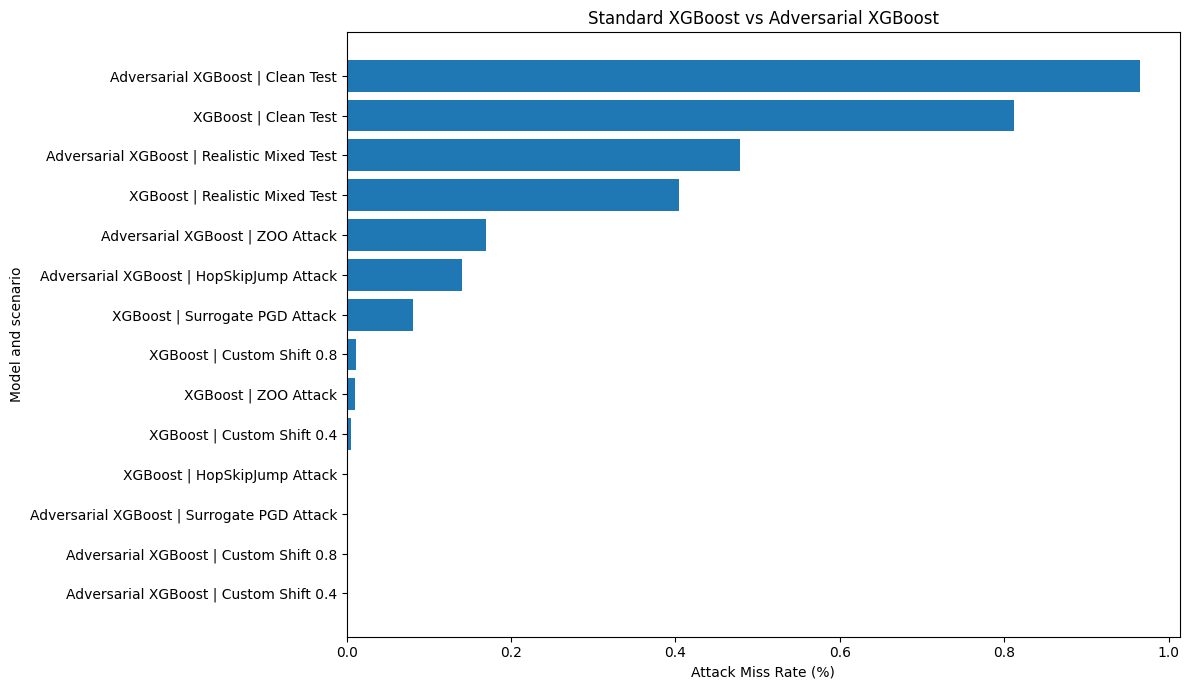

In [222]:
# 15.13 Plot standard vs robust miss rate
plot_df = xgb_standard_vs_robust_df[
    ["Model", "Scenario", "Attack Miss Rate (%)"]
].copy()

plot_df["Label"] = plot_df["Model"] + " | " + plot_df["Scenario"]
plot_df = plot_df.sort_values("Attack Miss Rate (%)", ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["Label"], plot_df["Attack Miss Rate (%)"])
plt.xlabel("Attack Miss Rate (%)")
plt.ylabel("Model and scenario")
plt.title("Standard XGBoost vs Adversarial XGBoost")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    results_dir / "xgboost_standard_vs_robust_miss_rate.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 15.14 Save classification reports

In [223]:
# 15.14 Save classification reports
standard_clean_pred = (
    xgb_model.predict_proba(X_test)[:, 1] >= selected_threshold
).astype(np.int64)

robust_clean_pred = (
    xgb_robust_model.predict_proba(X_test)[:, 1] >= robust_threshold
).astype(np.int64)

standard_mixed_pred = (
    xgb_model.predict_proba(X_mixed_test)[:, 1] >= selected_threshold
).astype(np.int64)

robust_mixed_pred = (
    xgb_robust_model.predict_proba(X_mixed_test)[:, 1] >= robust_threshold
).astype(np.int64)

reports = {
    "standard_xgboost_clean": classification_report(y_test, standard_clean_pred),
    "robust_xgboost_clean": classification_report(y_test, robust_clean_pred),
    "standard_xgboost_mixed": classification_report(y_mixed_test, standard_mixed_pred),
    "robust_xgboost_mixed": classification_report(y_mixed_test, robust_mixed_pred),
}

for report_name, report_text in reports.items():
    report_path = results_dir / f"{report_name}_classification_report.txt"
    report_path.write_text(report_text, encoding="utf-8")

print(reports["standard_xgboost_clean"])
print(reports["robust_xgboost_clean"])

              precision    recall  f1-score   support

           0       0.96      0.97      0.96    219639
           1       0.99      0.99      0.99   1180360

    accuracy                           0.99   1399999
   macro avg       0.98      0.98      0.98   1399999
weighted avg       0.99      0.99      0.99   1399999

              precision    recall  f1-score   support

           0       0.95      0.98      0.96    219639
           1       1.00      0.99      0.99   1180360

    accuracy                           0.99   1399999
   macro avg       0.97      0.98      0.98   1399999
weighted avg       0.99      0.99      0.99   1399999



### 15.15 Save final adversarial phase summary

In [224]:
# 15.15 Save final adversarial phase summary
adversarial_phase_summary = {
    "standard_model": "XGBoost",
    "standard_threshold": float(selected_threshold),
    "standard_threshold_reason": selected_threshold_reason,
    "robust_model": "Adversarial XGBoost",
    "robust_threshold": float(robust_threshold),
    "robust_threshold_reason": robust_threshold_reason,
    "robust_training_time_seconds": float(robust_training_time),
    "zoo_samples": int(len(X_xgb_zoo)),
    "hsj_samples": int(len(X_xgb_hsj)),
    "pgd_samples": int(len(X_xgb_pgd)),
    "custom_shift_samples": int(len(X_test)),
    "mixed_test_samples": int(len(X_mixed_test)),
    "main_security_metric": "Attack Miss Rate (%)",
}

summary_path = results_dir / "xgboost_adversarial_phase_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(adversarial_phase_summary, f, indent=2)

adversarial_phase_summary

{'standard_model': 'XGBoost',
 'standard_threshold': 0.454,
 'standard_threshold_reason': 'security_aggressive_low_fn_threshold',
 'robust_model': 'Adversarial XGBoost',
 'robust_threshold': 0.53,
 'robust_threshold_reason': 'target_miss_then_lowest_far',
 'robust_training_time_seconds': 14.143406200004392,
 'zoo_samples': 10000,
 'hsj_samples': 5000,
 'pgd_samples': 10000,
 'custom_shift_samples': 1399999,
 'mixed_test_samples': 2824998,
 'main_security_metric': 'Attack Miss Rate (%)'}

## Step 16: Final Artifacts and Binary Gate Export

This step saves the final operational XGBoost choice, hierarchy handoff files, threshold notes, tuning summary, SHAP feature table, and artifact manifest.


### 16.1 Clean standard vs robust adversarial comparison

This cell creates the corrected standard-vs-robust adversarial comparison table for paper/reporting use.


In [207]:
# 16.1 Clean standard vs robust adversarial comparison
attack_only_scenarios = [
    "ZOO Attack",
    "HopSkipJump Attack",
    "Surrogate PGD Attack",
]

xgb_standard_vs_robust_cleaned_df = xgb_standard_vs_robust_df.copy()

xgb_standard_vs_robust_cleaned_df["Samples"] = (
    xgb_standard_vs_robust_cleaned_df["TN"]
    + xgb_standard_vs_robust_cleaned_df["FP"]
    + xgb_standard_vs_robust_cleaned_df["FN"]
    + xgb_standard_vs_robust_cleaned_df["TP"]
)

xgb_standard_vs_robust_cleaned_df["Evaluation Type"] = "Full test"
xgb_standard_vs_robust_cleaned_df.loc[
    xgb_standard_vs_robust_cleaned_df["Scenario"].isin(attack_only_scenarios),
    "Evaluation Type",
] = "Attack-only"

misleading_columns = [
    "F1-Macro",
    "F1-Weighted",
    "MCC",
    "False Alarm Rate (%)",
    "ROC-AUC",
    "PR-AUC",
]

attack_only_mask = xgb_standard_vs_robust_cleaned_df["Evaluation Type"] == "Attack-only"
xgb_standard_vs_robust_cleaned_df.loc[attack_only_mask, misleading_columns] = np.nan

cleaned_comparison_path = (
    results_dir / "xgboost_standard_vs_robust_adversarial_comparison_cleaned.csv"
)
xgb_standard_vs_robust_cleaned_df.to_csv(cleaned_comparison_path, index=False)

print("Saved:", cleaned_comparison_path)
xgb_standard_vs_robust_cleaned_df

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_standard_vs_robust_adversarial_comparison_cleaned.csv


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Threshold Reason,Training Time (s),Samples,Evaluation Type
0,0.988463,0.994424,0.991878,0.993149,0.978316,0.988463,0.988495,0.956663,0.812210,2.988996,...,0.999024,0.999822,XGBoost,Clean Test,0.454,0.662336,NaN,NaN,1399999,Full test
1,0.999900,1.000000,0.999900,0.999950,NaN,0.999900,NaN,NaN,0.010000,NaN,...,NaN,NaN,XGBoost,ZOO Attack,0.454,0.032978,NaN,NaN,10000,Attack-only
2,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,NaN,0.000000,NaN,...,NaN,NaN,XGBoost,HopSkipJump Attack,0.454,0.006608,NaN,NaN,5000,Attack-only
3,0.999200,1.000000,0.999200,0.999600,NaN,0.999200,NaN,NaN,0.080000,NaN,...,NaN,NaN,XGBoost,Surrogate PGD Attack,0.454,0.038584,NaN,NaN,10000,Attack-only
4,0.995267,0.994469,0.999948,0.997201,0.990945,0.995267,0.995238,0.982046,0.005168,2.988996,...,0.999963,0.999993,XGBoost,Custom Shift 0.4,0.454,0.673345,NaN,NaN,1399999,Full test
5,0.995213,0.994468,0.999884,0.997169,0.990843,0.995213,0.995184,0.981838,0.011607,2.988996,...,0.999894,0.999980,XGBoost,Custom Shift 0.8,0.454,0.587497,NaN,NaN,1399999,Full test
6,0.988194,0.995630,0.990344,0.992980,0.977941,0.988194,0.988261,0.956017,0.965638,2.336106,...,0.998995,0.999817,Adversarial XGBoost,Clean Test,0.530,1.267802,target_miss_then_lowest_far,14.143406,1399999,Full test
7,0.998300,1.000000,0.998300,0.999149,NaN,0.998300,NaN,NaN,0.170000,NaN,...,NaN,NaN,Adversarial XGBoost,ZOO Attack,0.530,0.010211,target_miss_then_lowest_far,14.143406,10000,Attack-only
8,0.998600,1.000000,0.998600,0.999300,NaN,0.998600,NaN,NaN,0.140000,NaN,...,NaN,NaN,Adversarial XGBoost,HopSkipJump Attack,0.530,0.006504,target_miss_then_lowest_far,14.143406,5000,Attack-only
9,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,NaN,0.000000,NaN,...,NaN,NaN,Adversarial XGBoost,Surrogate PGD Attack,0.530,0.006744,target_miss_then_lowest_far,14.143406,10000,Attack-only


### 16.2 Save separated adversarial tables

This avoids mixing full-test and attack-only scenarios in the same interpretation.

In [208]:
# 16.2 Save separated adversarial tables
full_test_adversarial_df = xgb_standard_vs_robust_cleaned_df[
    xgb_standard_vs_robust_cleaned_df["Evaluation Type"] == "Full test"
].copy()

attack_only_adversarial_df = xgb_standard_vs_robust_cleaned_df[
    xgb_standard_vs_robust_cleaned_df["Evaluation Type"] == "Attack-only"
].copy()

full_test_adversarial_path = results_dir / "xgboost_adversarial_full_test_scenarios.csv"
attack_only_adversarial_path = results_dir / "xgboost_adversarial_attack_only_scenarios.csv"

full_test_adversarial_df.to_csv(full_test_adversarial_path, index=False)
attack_only_adversarial_df.to_csv(attack_only_adversarial_path, index=False)

print("Saved:", full_test_adversarial_path)
print("Saved:", attack_only_adversarial_path)

display(full_test_adversarial_df)
attack_only_adversarial_df

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_adversarial_full_test_scenarios.csv
Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_adversarial_attack_only_scenarios.csv


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Threshold Reason,Training Time (s),Samples,Evaluation Type
0,0.988463,0.994424,0.991878,0.993149,0.978316,0.988463,0.988495,0.956663,0.812210,2.988996,...,0.999024,0.999822,XGBoost,Clean Test,0.454,0.662336,NaN,NaN,1399999,Full test
4,0.995267,0.994469,0.999948,0.997201,0.990945,0.995267,0.995238,0.982046,0.005168,2.988996,...,0.999963,0.999993,XGBoost,Custom Shift 0.4,0.454,0.673345,NaN,NaN,1399999,Full test
5,0.995213,0.994468,0.999884,0.997169,0.990843,0.995213,0.995184,0.981838,0.011607,2.988996,...,0.999894,0.999980,XGBoost,Custom Shift 0.8,0.454,0.587497,NaN,NaN,1399999,Full test
6,0.988194,0.995630,0.990344,0.992980,0.977941,0.988194,0.988261,0.956017,0.965638,2.336106,...,0.998995,0.999817,Adversarial XGBoost,Clean Test,0.530,1.267802,target_miss_then_lowest_far,14.143406,1399999,Full test
10,0.996335,0.995672,1.000000,0.997831,0.993006,0.996335,0.996317,0.986109,0.000000,2.336106,...,1.000000,1.000000,Adversarial XGBoost,Custom Shift 0.4,0.530,1.089690,target_miss_then_lowest_far,14.143406,1399999,Full test
11,0.996335,0.995672,1.000000,0.997831,0.993006,0.996335,0.996317,0.986109,0.000000,2.336106,...,1.000000,1.000000,Adversarial XGBoost,Custom Shift 0.8,0.530,1.160177,target_miss_then_lowest_far,14.143406,1399999,Full test
12,0.991933,0.994504,0.995951,0.995227,0.984593,0.991933,0.991920,0.969196,0.404867,2.988996,...,0.999497,0.999909,XGBoost,Realistic Mixed Test,0.454,1.137449,security_aggressive_low_fn_threshold,NaN,2824998,Full test
13,0.992324,0.995696,0.995212,0.995454,0.985403,0.992324,0.992328,0.970807,0.478765,2.336106,...,0.999502,0.999910,Adversarial XGBoost,Realistic Mixed Test,0.530,2.232947,target_miss_then_lowest_far,14.143406,2824998,Full test


,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,MCC,Attack Miss Rate (%),False Alarm Rate (%),...,ROC-AUC,PR-AUC,Model,Scenario,Threshold,Inference Time (s),Threshold Reason,Training Time (s),Samples,Evaluation Type
1,0.9999,1.0,0.9999,0.999950,NaN,0.9999,NaN,NaN,0.01,NaN,...,NaN,NaN,XGBoost,ZOO Attack,0.454,0.032978,NaN,NaN,10000,Attack-only
2,1.0000,1.0,1.0000,1.000000,NaN,1.0000,NaN,NaN,0.00,NaN,...,NaN,NaN,XGBoost,HopSkipJump Attack,0.454,0.006608,NaN,NaN,5000,Attack-only
3,0.9992,1.0,0.9992,0.999600,NaN,0.9992,NaN,NaN,0.08,NaN,...,NaN,NaN,XGBoost,Surrogate PGD Attack,0.454,0.038584,NaN,NaN,10000,Attack-only
7,0.9983,1.0,0.9983,0.999149,NaN,0.9983,NaN,NaN,0.17,NaN,...,NaN,NaN,Adversarial XGBoost,ZOO Attack,0.530,0.010211,target_miss_then_lowest_far,14.143406,10000,Attack-only
8,0.9986,1.0,0.9986,0.999300,NaN,0.9986,NaN,NaN,0.14,NaN,...,NaN,NaN,Adversarial XGBoost,HopSkipJump Attack,0.530,0.006504,target_miss_then_lowest_far,14.143406,5000,Attack-only
9,1.0000,1.0,1.0000,1.000000,NaN,1.0000,NaN,NaN,0.00,NaN,...,NaN,NaN,Adversarial XGBoost,Surrogate PGD Attack,0.530,0.006744,target_miss_then_lowest_far,14.143406,10000,Attack-only


### 16.3 Optional separated adversarial plots

These replace the confusing mixed plot. Use them only if the paper needs plots.

In [209]:
# 16.3 Optional separated adversarial plots
full_plot_df = full_test_adversarial_df.sort_values(
    ["Scenario", "Model"]
).copy()

plt.figure(figsize=(10, 5))
for model_name, group_df in full_plot_df.groupby("Model"):
    plt.plot(
        group_df["Scenario"],
        group_df["Attack Miss Rate (%)"],
        marker="o",
        label=model_name,
    )

plt.ylabel("Attack Miss Rate (%)")
plt.xlabel("Full-test scenario")
plt.title("Full-Test Adversarial Scenarios")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()

full_plot_path = results_dir / "xgboost_adversarial_full_test_scenarios.png"
plt.savefig(full_plot_path, dpi=300, bbox_inches="tight")
plt.close()

attack_plot_df = attack_only_adversarial_df.sort_values(
    ["Scenario", "Model"]
).copy()

plt.figure(figsize=(10, 5))
for model_name, group_df in attack_plot_df.groupby("Model"):
    plt.plot(
        group_df["Scenario"],
        group_df["Attack Miss Rate (%)"],
        marker="o",
        label=model_name,
    )

plt.ylabel("Attack Miss Rate (%)")
plt.xlabel("Attack-only scenario")
plt.title("Attack-Only Adversarial Scenarios")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()

attack_plot_path = results_dir / "xgboost_adversarial_attack_only_scenarios.png"
plt.savefig(attack_plot_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved:", full_plot_path)
print("Saved:", attack_plot_path)

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_adversarial_full_test_scenarios.png
Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_adversarial_attack_only_scenarios.png


### 16.4 Save the three-threshold XGBoost comparison

This documents why threshold `0.454` was selected as the security-aggressive operating point.

In [210]:
# 16.4 Save the three-threshold XGBoost comparison
xgb_three_thresholds_path = results_dir / "xgboost_three_thresholds_test_comparison.csv"
xgb_three_thresholds_df.to_csv(xgb_three_thresholds_path, index=False)

print("Saved:", xgb_three_thresholds_path)
xgb_three_thresholds_df

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_three_thresholds_test_comparison.csv


,Model,Threshold Label,Threshold,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,MCC,Attack Miss Rate (%),False Alarm Rate (%),FP,FN,TP,TN,Total Errors,ROC-AUC,PR-AUC,Inference Time per Flow (us)
0,XGBoost,Security-aggressive,0.454,0.988463,0.994424,0.991878,0.993149,0.978316,0.956663,0.812210,2.988996,6565,9587,1170773,213074,16152,0.999024,0.999822,0.434902
1,XGBoost,Original calibration,0.530,0.988406,0.995812,0.990413,0.993105,0.978342,0.956826,0.958691,2.238218,4916,11316,1169044,214723,16232,0.999024,0.999822,0.434902
2,XGBoost,Refined operational,0.533,0.988408,0.995867,0.990361,0.993106,0.978351,0.956849,0.963858,2.209079,4852,11377,1168983,214787,16229,0.999024,0.999822,0.434902


### 16.5 Save final XGBoost operational selection


In [211]:
# 16.5 Save final XGBoost operational selection
selected_threshold_row = xgb_three_thresholds_df[
    xgb_three_thresholds_df["Threshold"].round(3) == round(float(selected_threshold), 3)
].copy()

selected_metrics = selected_threshold_row.iloc[0].to_dict()

xgb_selection_payload = {
    "selected_model": selected_model_name,
    "selected_threshold": float(selected_threshold),
    "threshold_reason": selected_threshold_reason,
    "model_path": str(models_dir / "xgboost_optuna40.joblib"),
    "selection_reason": (
        "XGBoost was selected as the operational binary gate because it gives the best "
        "security and deployment trade-off: low attack miss rate, acceptable false alarm "
        "rate, strong F1/MCC, fast inference, and SHAP-compatible explainability."
    ),
    "test_metrics_at_selected_threshold": selected_metrics,
}

xgb_selection_path = results_dir / "xgboost_final_operational_selection.json"
with open(xgb_selection_path, "w", encoding="utf-8") as f:
    json.dump(xgb_selection_payload, f, indent=2, default=str)

print("Saved:", xgb_selection_path)
xgb_selection_payload

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_final_operational_selection.json


{'selected_model': 'XGBoost',
 'selected_threshold': 0.454,
 'threshold_reason': 'security_aggressive_low_fn_threshold',
 'model_path': 'D:\\Ml Project\\prepared_final-20260304T163925Z-3-001\\prepared_final\\ML Project_ FINAL\\Hierarchical IoT Intrusion Detection\\Hierarchical-IoT-Intrusion-Detection\\models\\reviewer3_binary\\xgboost_optuna40.joblib',
 'selection_reason': 'XGBoost was selected as the operational binary gate because it gives the best security and deployment trade-off: low attack miss rate, acceptable false alarm rate, strong F1/MCC, fast inference, and SHAP-compatible explainability.',
 'test_metrics_at_selected_threshold': {'Model': 'XGBoost',
  'Threshold Label': 'Security-aggressive',
  'Threshold': 0.454,
  'Accuracy': 0.988462848902035,
  'Precision': 0.994423861287073,
  'Attack Recall': 0.9918779016571215,
  'F1-Binary': 0.9931492498191032,
  'F1-Macro': 0.978315524751288,
  'MCC': 0.9566629229288673,
  'Attack Miss Rate (%)': 0.8122098342878444,
  'False Alarm 

### 16.6 Save final XGBoost operational config


In [212]:
# 16.6 Save final XGBoost operational config
xgb_operational_config = {
    "stage": "binary_gate",
    "model": "XGBoost",
    "model_path": str(models_dir / "xgboost_optuna40.joblib"),
    "selected_threshold": float(selected_threshold),
    "threshold_reason": selected_threshold_reason,
    "best_params": best_params.get("XGBoost", {}),
    "n_features": int(len(feature_names)),
    "feature_names": list(feature_names),
    "processed_data_path": str(processed_dir),
    "feature_protocol_path": str(results_dir / "binary_stage_feature_protocol.json"),
    "selection_file": str(results_dir / "xgboost_final_operational_selection.json"),
    "kfold_summary_path": str(results_dir / "xgboost_fixed_threshold_0454_stratified_kfold_summary.csv"),
}

xgb_config_path = results_dir / "xgboost_final_operational_config.json"
with open(xgb_config_path, "w", encoding="utf-8") as f:
    json.dump(xgb_operational_config, f, indent=2, default=str)

print("Saved:", xgb_config_path)
xgb_operational_config

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_final_operational_config.json


{'stage': 'binary_gate',
 'model': 'XGBoost',
 'model_path': 'D:\\Ml Project\\prepared_final-20260304T163925Z-3-001\\prepared_final\\ML Project_ FINAL\\Hierarchical IoT Intrusion Detection\\Hierarchical-IoT-Intrusion-Detection\\models\\reviewer3_binary\\xgboost_optuna40.joblib',
 'selected_threshold': 0.454,
 'threshold_reason': 'security_aggressive_low_fn_threshold',
 'best_params': {'n_estimators': 494,
  'max_depth': 12,
  'learning_rate': 0.07169176308098478,
  'subsample': 0.6136054592927314,
  'colsample_bytree': 0.6102230462328162,
  'min_child_weight': 3,
  'gamma': 0.7746240578772603,
  'reg_alpha': 1.8843779447406206,
  'reg_lambda': 1.5905193083604048,
  'scale_pos_weight': 1.0,
  'objective': 'binary:logistic',
  'eval_metric': 'aucpr',
  'tree_method': 'hist',
  'device': 'cuda',
  'random_state': 42},
 'n_features': 46,
 'feature_names': ['flow_duration',
  'Header_Length',
  'Protocol Type',
  'Duration',
  'Rate',
  'Srate',
  'Drate',
  'fin_flag_number',
  'syn_flag_n

### 16.7 Save comparison table with operational XGBoost row


In [213]:
# 16.7 Save comparison table with operational XGBoost row
operational_comparison_df = comparison_df.copy()

xgb_operational_row = xgb_three_thresholds_df[
    xgb_three_thresholds_df["Threshold"].round(3) == round(float(selected_threshold), 3)
].copy()

xgb_operational_row["Model"] = "XGBoost (Operational 0.454)"
xgb_operational_row["Threshold Reason"] = selected_threshold_reason

common_cols = [
    col for col in operational_comparison_df.columns
    if col in xgb_operational_row.columns
]
xgb_operational_row = xgb_operational_row[common_cols]

operational_comparison_df = pd.concat(
    [operational_comparison_df, xgb_operational_row],
    ignore_index=True,
)

operational_comparison_path = (
    results_dir / "fair_binary_comparison_with_operational_xgboost.csv"
)
operational_comparison_df.to_csv(operational_comparison_path, index=False)

print("Saved:", operational_comparison_path)
operational_comparison_df

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\fair_binary_comparison_with_operational_xgboost.csv


,Model,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,F1-Micro,F1-Weighted,ROC-AUC,PR-AUC,MCC,Attack Miss Rate (%),False Alarm Rate (%),Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time (s),Inference Time per Flow (us)
0,Decision Tree,0.986527,0.993707,0.990292,0.991996,0.974725,0.986527,0.986577,0.996933,0.999137,0.949507,0.970806,3.370531,0.150,target_miss_then_lowest_far,139.439641,60.570803,0.091344,0.065246
1,Random Forest,0.988088,0.995648,0.990200,0.992916,0.977751,0.988088,0.988158,0.998853,0.999793,0.955645,0.980040,2.326090,0.420,target_miss_then_lowest_far,13227.308782,705.834088,9.967020,7.119305
2,XGBoost,0.988406,0.995812,0.990413,0.993105,0.978342,0.988406,0.988473,0.999024,0.999822,0.956826,0.958691,2.238218,0.530,target_miss_then_lowest_far,181.779670,12.903665,0.778192,0.555852
3,MLP,0.974702,0.979367,0.990871,0.985085,0.950916,0.974702,0.974364,0.996663,0.999401,0.902517,0.912942,11.218864,0.090,target_miss_then_lowest_far,10831.383007,1225.454924,8.855724,6.325522
4,XGBoost (Operational 0.454),0.988463,0.994424,0.991878,0.993149,0.978316,NaN,NaN,0.999024,0.999822,0.956663,0.812210,2.988996,0.454,security_aggressive_low_fn_threshold,NaN,NaN,NaN,0.434902


### 16.8 Save best parameters, threshold notes, and tuning summary


In [214]:
# 16.8 Save best parameters, threshold notes, and tuning summary
threshold_notes["XGBoost Operational"] = {
    "threshold": float(selected_threshold),
    "reason": selected_threshold_reason,
    "policy": "security_aggressive_low_fn_threshold",
}

best_params_path = results_dir / "reviewer3_best_params.json"
threshold_notes_path = results_dir / "reviewer3_threshold_notes.json"

with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, default=str)

with open(threshold_notes_path, "w", encoding="utf-8") as f:
    json.dump(threshold_notes, f, indent=2, default=str)

tuning_summary_cols = [
    "Model",
    "Threshold",
    "Threshold Reason",
    "Tuning Time (s)",
    "Training Time (s)",
    "Inference Time per Flow (us)",
]

reviewer3_tuning_summary_df = comparison_df[tuning_summary_cols].copy()
reviewer3_tuning_summary_df["Optuna Trials"] = N_TRIALS
reviewer3_tuning_summary_df["Feature Set"] = "same_binary_base_features"

tuning_summary_path = results_dir / "reviewer3_tuning_summary.csv"
reviewer3_tuning_summary_df.to_csv(tuning_summary_path, index=False)

print("Saved:", best_params_path)
print("Saved:", threshold_notes_path)
print("Saved:", tuning_summary_path)
reviewer3_tuning_summary_df

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\reviewer3_best_params.json
Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\reviewer3_threshold_notes.json
Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\reviewer3_tuning_summary.csv


,Model,Threshold,Threshold Reason,Tuning Time (s),Training Time (s),Inference Time per Flow (us),Optuna Trials,Feature Set
0,Decision Tree,0.15,target_miss_then_lowest_far,139.439641,60.570803,0.065246,40,same_binary_base_features
1,Random Forest,0.42,target_miss_then_lowest_far,13227.308782,705.834088,7.119305,40,same_binary_base_features
2,XGBoost,0.53,target_miss_then_lowest_far,181.779670,12.903665,0.555852,40,same_binary_base_features
3,MLP,0.09,target_miss_then_lowest_far,10831.383007,1225.454924,6.325522,40,same_binary_base_features


### 16.9 Save the binary-stage feature protocol


In [215]:
# 16.9 Save the binary-stage feature protocol
binary_feature_protocol = {
    "stage": "binary_gate",
    "target_definition": "benign_vs_attack",
    "n_features": int(len(feature_names)),
    "feature_names": list(feature_names),
    "processed_data_path": str(processed_dir),
    "train_file": str(processed_dir / "train_data.npz"),
    "test_file": str(processed_dir / "test_data.npz"),
    "metadata_file": str(processed_dir / "metadata.joblib"),
    "feature_columns_file": str(processed_dir / "feature_columns.joblib"),
    "scaler_file": str(processed_dir / "scaler.joblib"),
    "binary_class_weights_file": str(processed_dir / "binary_class_weights.joblib"),
    "feature_order_locked": True,
    "test_row_identity": "array_order_in_test_data_npz",
    "calibration_policy": (
        "Training data is split into fit_pool and calibration_pool. "
        "The test set is used only for final reporting."
    ),
    "metadata_keys": list(metadata.keys()) if hasattr(metadata, "keys") else [],
}

binary_feature_protocol_path = results_dir / "binary_stage_feature_protocol.json"
with open(binary_feature_protocol_path, "w", encoding="utf-8") as f:
    json.dump(binary_feature_protocol, f, indent=2, default=str)

print("Saved:", binary_feature_protocol_path)
binary_feature_protocol

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\binary_stage_feature_protocol.json


{'stage': 'binary_gate',
 'target_definition': 'benign_vs_attack',
 'n_features': 46,
 'feature_names': ['flow_duration',
  'Header_Length',
  'Protocol Type',
  'Duration',
  'Rate',
  'Srate',
  'Drate',
  'fin_flag_number',
  'syn_flag_number',
  'rst_flag_number',
  'psh_flag_number',
  'ack_flag_number',
  'ece_flag_number',
  'cwr_flag_number',
  'ack_count',
  'syn_count',
  'fin_count',
  'urg_count',
  'rst_count',
  'HTTP',
  'HTTPS',
  'DNS',
  'Telnet',
  'SMTP',
  'SSH',
  'IRC',
  'TCP',
  'UDP',
  'DHCP',
  'ARP',
  'ICMP',
  'IPv',
  'LLC',
  'Tot sum',
  'Min',
  'Max',
  'AVG',
  'Std',
  'Tot size',
  'IAT',
  'Number',
  'Magnitue',
  'Radius',
  'Covariance',
  'Variance',
  'Weight'],
 'processed_data_path': 'D:\\Ml Project\\processed_data',
 'train_file': 'D:\\Ml Project\\processed_data\\train_data.npz',
 'test_file': 'D:\\Ml Project\\processed_data\\test_data.npz',
 'metadata_file': 'D:\\Ml Project\\processed_data\\metadata.joblib',
 'feature_columns_file': 'D:\

### 16.10 Save binary test predictions for the hierarchy


In [216]:
# 16.10 Save binary test predictions for the hierarchy
binary_stage_prob = xgb_selected_prob.astype(np.float32)
binary_stage_pred = (binary_stage_prob >= selected_threshold).astype(np.int64)
binary_test_row_index = np.arange(len(y_test), dtype=np.int64)

binary_predictions_path = results_dir / "binary_stage_test_predictions_threshold_0454.npz"
np.savez_compressed(
    binary_predictions_path,
    y_true_binary=y_test.astype(np.int64),
    y_prob_binary=binary_stage_prob,
    y_pred_binary=binary_stage_pred,
    threshold=np.array([selected_threshold], dtype=np.float32),
    test_row_index=binary_test_row_index,
)

print("Saved:", binary_predictions_path)
print("Rows:", len(y_test))

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\binary_stage_test_predictions_threshold_0454.npz
Rows: 1399999


### 16.11 Save binary-stage summary for the hierarchy


In [217]:
# 16.11 Save binary-stage summary for the hierarchy
binary_summary_row = xgb_three_thresholds_df[
    xgb_three_thresholds_df["Threshold"].round(3) == round(float(selected_threshold), 3)
].copy()

binary_summary_row.insert(0, "Stage", "binary_gate")
binary_summary_row["Operational Use"] = "hierarchical_pipeline_entry_gate"
binary_summary_row["Selected Model Path"] = str(models_dir / "xgboost_optuna40.joblib")
binary_summary_row["Prediction Artifact"] = str(
    results_dir / "binary_stage_test_predictions_threshold_0454.npz"
)

binary_summary_path = results_dir / "binary_stage_summary_for_hierarchy.csv"
binary_summary_row.to_csv(binary_summary_path, index=False)

print("Saved:", binary_summary_path)
binary_summary_row

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\binary_stage_summary_for_hierarchy.csv


,Stage,Model,Threshold Label,Threshold,Accuracy,Precision,Attack Recall,F1-Binary,F1-Macro,MCC,...,FN,TP,TN,Total Errors,ROC-AUC,PR-AUC,Inference Time per Flow (us),Operational Use,Selected Model Path,Prediction Artifact
0,binary_gate,XGBoost,Security-aggressive,0.454,0.988463,0.994424,0.991878,0.993149,0.978316,0.956663,...,9587,1170773,213074,16152,0.999024,0.999822,0.434902,hierarchical_pipeline_entry_gate,D:\Ml Project\prepared_final-20260304T163925Z-...,D:\Ml Project\prepared_final-20260304T163925Z-...


### 16.12 Save SHAP top features as CSV


In [218]:
# 16.12 Save SHAP top features as CSV
if RUN_XGB_SHAP:
    shap_importance = np.abs(xgb_shap_values).mean(axis=0)
    shap_top_features_df = pd.DataFrame({
        "Feature": feature_names,
        "MeanAbsSHAP": shap_importance,
    })

    shap_top_features_df = shap_top_features_df.sort_values(
        "MeanAbsSHAP",
        ascending=False,
    ).reset_index(drop=True)

    shap_top_features_df.insert(
        0,
        "Rank",
        np.arange(1, len(shap_top_features_df) + 1),
    )

    shap_top_features_path = results_dir / "xgboost_shap_top_features.csv"
    shap_top_features_df.to_csv(shap_top_features_path, index=False)

    print("Saved:", shap_top_features_path)
    display(shap_top_features_df.head(20))

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_shap_top_features.csv


,Rank,Feature,MeanAbsSHAP
0,1,IAT,3.306278
1,2,rst_count,1.561662
2,3,Number,0.913095
3,4,urg_count,0.828749
4,5,Max,0.783550
5,6,Tot size,0.774831
6,7,flow_duration,0.507353
7,8,Weight,0.475719
8,9,Header_Length,0.428734
9,10,Variance,0.324404


### 16.13 Save XGBoost threshold trade-off plot


In [219]:
# 16.13 Save XGBoost threshold trade-off plot
threshold_plot_df = xgb_threshold_refinement_df.sort_values("Threshold").copy()

plt.figure(figsize=(9, 5))
plt.plot(
    threshold_plot_df["Threshold"],
    threshold_plot_df["Attack Miss Rate (%)"],
    label="Attack Miss Rate (%)",
)
plt.plot(
    threshold_plot_df["Threshold"],
    threshold_plot_df["False Alarm Rate (%)"],
    label="False Alarm Rate (%)",
)
plt.plot(
    threshold_plot_df["Threshold"],
    threshold_plot_df["F1-Binary"],
    label="F1-Binary",
)
plt.axvline(
    float(selected_threshold),
    color="black",
    linestyle="--",
    label="Selected 0.454",
)
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("XGBoost Threshold Trade-off on Calibration Data")
plt.legend()
plt.tight_layout()

threshold_tradeoff_path = results_dir / "xgboost_threshold_tradeoff_curve.png"
plt.savefig(threshold_tradeoff_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved:", threshold_tradeoff_path)

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\xgboost_threshold_tradeoff_curve.png


### 16.14 Save final artifact manifest


In [220]:
# 16.14 Save final artifact manifest
artifact_paths = [
    models_dir / "decision_tree_optuna40.joblib",
    models_dir / "random_forest_optuna40.joblib",
    models_dir / "xgboost_optuna40.joblib",
    models_dir / "mlp_optuna40.pt",
    models_dir / "xgboost_multi_adversarial_robust.joblib",
    results_dir / "fair_binary_comparison.csv",
    results_dir / "fair_binary_comparison_with_operational_xgboost.csv",
    results_dir / "xgboost_three_thresholds_test_comparison.csv",
    results_dir / "xgboost_final_operational_selection.json",
    results_dir / "xgboost_final_operational_config.json",
    results_dir / "reviewer3_best_params.json",
    results_dir / "reviewer3_threshold_notes.json",
    results_dir / "reviewer3_tuning_summary.csv",
    results_dir / "binary_stage_feature_protocol.json",
    results_dir / "binary_stage_test_predictions_threshold_0454.npz",
    results_dir / "binary_stage_summary_for_hierarchy.csv",
    results_dir / "xgboost_fixed_threshold_0454_stratified_kfold.csv",
    results_dir / "xgboost_fixed_threshold_0454_stratified_kfold_summary.csv",
    results_dir / "xgboost_shap_top_features.csv",
    results_dir / "xgboost_continuation_shap_summary.png",
    results_dir / "xgboost_continuation_shap_bar.png",
    results_dir / "xgboost_threshold_tradeoff_curve.png",
    results_dir / "xgboost_only_adversarial_results.csv",
    results_dir / "xgboost_only_adversarial_results_cleaned.csv",
    results_dir / "xgboost_adversarial_perturbation_summary_corrected.csv",
    results_dir / "xgboost_adversarial_phase_notes.json",
    results_dir / "xgboost_robust_adversarial_results.csv",
    results_dir / "xgboost_standard_vs_robust_mixed_test.csv",
    results_dir / "xgboost_standard_vs_robust_adversarial_comparison.csv",
    results_dir / "xgboost_standard_vs_robust_adversarial_comparison_cleaned.csv",
    results_dir / "xgboost_adversarial_full_test_scenarios.csv",
    results_dir / "xgboost_adversarial_attack_only_scenarios.csv",
    results_dir / "xgboost_adversarial_full_test_scenarios.png",
    results_dir / "xgboost_adversarial_attack_only_scenarios.png",
    results_dir / "xgboost_adversarial_phase_summary.json",
    results_dir / "standard_xgboost_clean_classification_report.txt",
    results_dir / "robust_xgboost_clean_classification_report.txt",
    results_dir / "standard_xgboost_mixed_classification_report.txt",
    results_dir / "robust_xgboost_mixed_classification_report.txt",
]

manifest_rows = []
for path in artifact_paths:
    manifest_rows.append({
        "Artifact": path.name,
        "Path": str(path),
        "Exists": path.exists(),
        "Size Bytes": path.stat().st_size if path.exists() else 0,
    })

artifact_manifest_df = pd.DataFrame(manifest_rows)

artifact_manifest_csv_path = results_dir / "reviewer3_binary_artifact_manifest.csv"
artifact_manifest_json_path = results_dir / "reviewer3_binary_artifact_manifest.json"

artifact_manifest_df.to_csv(artifact_manifest_csv_path, index=False)

manifest_payload = {
    "stage": "reviewer3_binary",
    "binary_gate_model": "XGBoost",
    "binary_gate_threshold": float(selected_threshold),
    "robust_variant": "Adversarial XGBoost",
    "results_dir": str(results_dir),
    "models_dir": str(models_dir),
    "notes": (
        "Standard XGBoost remains the operational binary gate. "
        "Adversarial XGBoost is saved as a robustness analysis variant."
    ),
    "artifacts": manifest_rows,
}

with open(artifact_manifest_json_path, "w", encoding="utf-8") as f:
    json.dump(manifest_payload, f, indent=2, default=str)

print("Saved:", artifact_manifest_csv_path)
print("Saved:", artifact_manifest_json_path)
artifact_manifest_df

Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\reviewer3_binary_artifact_manifest.csv
Saved: D:\Ml Project\prepared_final-20260304T163925Z-3-001\prepared_final\ML Project_ FINAL\Hierarchical IoT Intrusion Detection\Hierarchical-IoT-Intrusion-Detection\results\reviewer3_binary\reviewer3_binary_artifact_manifest.json


,Artifact,Path,Exists,Size Bytes
0,decision_tree_optuna40.joblib,D:\Ml Project\prepared_final-20260304T163925Z-...,True,954329
1,random_forest_optuna40.joblib,D:\Ml Project\prepared_final-20260304T163925Z-...,True,2960197465
2,xgboost_optuna40.joblib,D:\Ml Project\prepared_final-20260304T163925Z-...,True,14576330
3,mlp_optuna40.pt,D:\Ml Project\prepared_final-20260304T163925Z-...,True,3686900
4,xgboost_multi_adversarial_robust.joblib,D:\Ml Project\prepared_final-20260304T163925Z-...,True,14622721
5,fair_binary_comparison.csv,D:\Ml Project\prepared_final-20260304T163925Z-...,True,1607
6,fair_binary_comparison_with_operational_xgboos...,D:\Ml Project\prepared_final-20260304T163925Z-...,True,1890
7,xgboost_three_thresholds_test_comparison.csv,D:\Ml Project\prepared_final-20260304T163925Z-...,True,1023
8,xgboost_final_operational_selection.json,D:\Ml Project\prepared_final-20260304T163925Z-...,True,1316
9,xgboost_final_operational_config.json,D:\Ml Project\prepared_final-20260304T163925Z-...,True,2548


## Final Binary Gate Decision

Final operational binary gate: Standard XGBoost at threshold 0.454.

The MLP is retained as the neural-network baseline required for a fair comparison, not as the deployed binary gate. The adversarially trained XGBoost is retained as a robustness analysis artifact, not as a replacement for the selected standard XGBoost gate.
